<a href="https://colab.research.google.com/github/nagayada/Nag_New_Repo/blob/main/EDA_Assg_NYC_Taxi_Starter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [2]:
# Import warnings
import warnings
warnings.filterwarnings('ignore')


In [ ]:
# Import the libraries you will be using for analysis
!pip install numpy==1.26.4
!pip install pandas==2.2.2
!pip install matplotlib==3.10.0
!pip install seaborn==0.13.2



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 43.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 5.0.0.93 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which 

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/base_command.py", line 179, in exc_logging_wrapper
    status = run_func(*args)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pip/_internal/cli/req_command.py", line 67, in wrapper
^C


In [1]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [2]:
# Try loading one file

df = pd.read_parquet('/content/drive/MyDrive/EDA_files/2023-1.parquet')
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

In [ ]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files
import os

# Select the folder having data files
os.chdir('/content/drive/MyDrive/EDA_files')

# Create a list of all the twelve files to read
file_list = os.listdir()

# initialise an empty dataframe for the combined sampled data
yearly_sampled_df = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(os.getcwd(), file_name)

        # Reading the current file
        month_df = pd.read_parquet(file_path)

        # Ensure datetime column is in datetime format
        month_df['tpep_pickup_datetime'] = pd.to_datetime(month_df['tpep_pickup_datetime'])

        # Create 'date' and 'hour' columns for sampling
        month_df['date'] = month_df['tpep_pickup_datetime'].dt.date
        month_df['hour'] = month_df['tpep_pickup_datetime'].dt.hour

        # We will store the sampled data for the current month in this df
        sampled_month_data = pd.DataFrame()

        # Loop through unique dates in the current month
        for date in month_df['date'].unique():
            daily_data = month_df[month_df['date'] == date]

            # Iterate through each hour of the selected date
            for hour in daily_data['hour'].unique():
                hour_data = daily_data[daily_data['hour'] == hour]

                # Sample 5% of the hourly data randomly
                if not hour_data.empty:
                    sample = hour_data.sample(frac=0.05, random_state=42)
                    sampled_month_data = pd.concat([sampled_month_data, sample], ignore_index=True)

        # Concatenate the sampled data of the current month to the combined dataframe
        yearly_sampled_df = pd.concat([yearly_sampled_df, sampled_month_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")

# The final combined and sampled dataframe is 'yearly_sampled_df'
df = yearly_sampled_df

# Display info for the final sampled DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [6]:
# Store the df in csv/parquet
df.to_parquet('/content/drive/MyDrive/sampled_taxi_trips_2023.parquet', index=False)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [ ]:
# Load the new data file



In [7]:
df = pd.read_parquet('/content/drive/MyDrive/sampled_taxi_trips_2023.parquet')


In [8]:
# df.head()
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,date,hour,airport_fee
0,1,2023-04-01 00:58:33,2023-04-01 01:07:03,4.0,1.10,1.0,Y,249,125,1,...,0.5,2.70,0.0,1.0,16.30,2.5,0.0,2023-04-01,0,NaN
1,1,2023-04-01 00:10:28,2023-04-01 00:27:17,1.0,3.00,1.0,N,230,114,2,...,0.5,0.00,0.0,1.0,21.30,2.5,0.0,2023-04-01,0,NaN
2,2,2023-04-01 00:54:11,2023-04-01 01:00:52,1.0,1.53,1.0,N,100,113,1,...,0.5,2.86,0.0,1.0,17.16,2.5,0.0,2023-04-01,0,NaN
3,1,2023-04-01 00:53:11,2023-04-01 01:04:05,2.0,1.50,1.0,N,90,164,1,...,0.5,3.40,0.0,1.0,20.50,2.5,0.0,2023-04-01,0,NaN
4,2,2023-04-01 00:38:39,2023-04-01 00:52:06,4.0,1.60,1.0,N,211,211,1,...,0.5,0.00,0.0,1.0,18.50,2.5,0.0,2023-04-01,0,NaN


In [9]:
# df.info()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [10]:
# Fix the index and drop any columns that are not needed
df = df.reset_index(drop=True)
df = df.drop(columns=['date', 'hour'])
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 20 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  Airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,airport_fee
0,1,2023-04-01 00:58:33,2023-04-01 01:07:03,4.0,1.10,1.0,Y,249,125,1,8.6,3.5,0.5,2.70,0.0,1.0,16.30,2.5,0.0,NaN
1,1,2023-04-01 00:10:28,2023-04-01 00:27:17,1.0,3.00,1.0,N,230,114,2,16.3,3.5,0.5,0.00,0.0,1.0,21.30,2.5,0.0,NaN
2,2,2023-04-01 00:54:11,2023-04-01 01:00:52,1.0,1.53,1.0,N,100,113,1,9.3,1.0,0.5,2.86,0.0,1.0,17.16,2.5,0.0,NaN
3,1,2023-04-01 00:53:11,2023-04-01 01:04:05,2.0,1.50,1.0,N,90,164,1,12.1,3.5,0.5,3.40,0.0,1.0,20.50,2.5,0.0,NaN
4,2,2023-04-01 00:38:39,2023-04-01 00:52:06,4.0,1.60,1.0,N,211,211,1,13.5,1.0,0.5,0.00,0.0,1.0,18.50,2.5,0.0,NaN


**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [11]:
# Combine the two airport fee columns
# Fill NaN values in 'airport_fee' with values from 'Airport_fee' and then drop 'Airport_fee'
# First, ensure both are numeric, coercing errors to NaN
df['airport_fee'] = pd.to_numeric(df['airport_fee'], errors='coerce')
df['Airport_fee'] = pd.to_numeric(df['Airport_fee'], errors='coerce')

# Combine by filling NaNs in one with values from the other
# We'll prioritize the lowercase 'airport_fee' column, filling its NaNs with values from 'Airport_fee'
df['airport_fee'] = df['airport_fee'].fillna(df['Airport_fee'])

# Drop the now redundant 'Airport_fee' column
df = df.drop(columns=['Airport_fee'])

# Finally, fill any remaining NaNs in the consolidated 'airport_fee' with 0, assuming no fee if not specified
df['airport_fee'] = df['airport_fee'].fillna(0)

df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896400 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2023-04-01 00:58:33,2023-04-01 01:07:03,4.0,1.10,1.0,Y,249,125,1,8.6,3.5,0.5,2.70,0.0,1.0,16.30,2.5,0.0
1,1,2023-04-01 00:10:28,2023-04-01 00:27:17,1.0,3.00,1.0,N,230,114,2,16.3,3.5,0.5,0.00,0.0,1.0,21.30,2.5,0.0
2,2,2023-04-01 00:54:11,2023-04-01 01:00:52,1.0,1.53,1.0,N,100,113,1,9.3,1.0,0.5,2.86,0.0,1.0,17.16,2.5,0.0
3,1,2023-04-01 00:53:11,2023-04-01 01:04:05,2.0,1.50,1.0,N,90,164,1,12.1,3.5,0.5,3.40,0.0,1.0,20.50,2.5,0.0
4,2,2023-04-01 00:38:39,2023-04-01 00:52:06,4.0,1.60,1.0,N,211,211,1,13.5,1.0,0.5,0.00,0.0,1.0,18.50,2.5,0.0


**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [12]:
# check where values of fare amount are negative
df[df['fare_amount'] < 0]

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee


Did you notice something different in the `RatecodeID` column for above records?

In [ ]:
# Analyse RatecodeID for the negative fare amounts



In [ ]:
# Find which columns have negative values

No Negattive values

In [ ]:
# fix these negative values



### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [13]:
# Find the proportion of missing values in each column

for col in df.select_dtypes(include=np.number).columns:
    if (df[col] < 0).any():
        print(f"Column '{col}' has negative values.")
        display(df[df[col] < 0].head())
    else:
        print(f"Column '{col}' does not have negative values.")

Column 'VendorID' does not have negative values.
Column 'passenger_count' does not have negative values.
Column 'trip_distance' does not have negative values.
Column 'RatecodeID' does not have negative values.
Column 'PULocationID' does not have negative values.
Column 'DOLocationID' does not have negative values.
Column 'payment_type' does not have negative values.
Column 'fare_amount' does not have negative values.
Column 'extra' has negative values.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
1090678,2,2023-10-06 22:24:42,2023-10-06 22:25:38,2.0,0.03,1.0,N,161,161,2,0.0,-1.0,-0.5,0.0,0.0,-1.0,-5.0,-2.5,0.0
1207227,2,2023-10-27 14:51:03,2023-10-27 14:51:11,1.0,0.00,1.0,N,265,265,2,3.0,-2.5,0.0,0.0,0.0,1.0,4.0,0.0,0.0
1599473,2,2023-11-06 22:37:04,2023-11-06 22:37:55,1.0,0.03,1.0,N,229,229,2,0.0,-1.0,-0.5,0.0,0.0,-1.0,-5.0,-2.5,0.0


Column 'mta_tax' has negative values.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
18600,2,2023-04-04 16:24:21,2023-04-04 16:24:28,4.0,0.00,1.0,N,264,264,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
22388,2,2023-04-10 18:40:15,2023-04-10 18:44:09,1.0,0.36,1.0,N,132,132,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75
38803,2,2023-04-12 19:12:27,2023-04-12 19:37:09,1.0,3.61,1.0,N,68,232,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
168788,2,2023-05-08 13:17:53,2023-05-08 13:18:11,1.0,0.00,1.0,N,7,7,1,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00
180172,2,2023-05-09 17:05:56,2023-05-09 17:24:59,1.0,8.35,1.0,N,132,222,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75


Column 'tip_amount' does not have negative values.
Column 'tolls_amount' does not have negative values.
Column 'improvement_surcharge' has negative values.


...

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
18600,2,2023-04-04 16:24:21,2023-04-04 16:24:28,4.0,0.00,1.0,N,264,264,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
22388,2,2023-04-10 18:40:15,2023-04-10 18:44:09,1.0,0.36,1.0,N,132,132,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75
38803,2,2023-04-12 19:12:27,2023-04-12 19:37:09,1.0,3.61,1.0,N,68,232,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.00,-2.5,0.00
101981,2,2023-04-24 12:48:38,2023-04-24 12:48:44,1.0,0.00,5.0,N,140,7,2,0.0,0.0,0.0,0.0,0.0,-1.0,-3.50,-2.5,0.00
168788,2,2023-05-08 13:17:53,2023-05-08 13:18:11,1.0,0.00,1.0,N,7,7,1,0.0,0.0,-0.5,0.0,0.0,-1.0,-1.50,0.0,0.00


Column 'congestion_surcharge' has negative values.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
18600,2,2023-04-04 16:24:21,2023-04-04 16:24:28,4.0,0.00,1.0,N,264,264,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.0,-2.5,0.0
38803,2,2023-04-12 19:12:27,2023-04-12 19:37:09,1.0,3.61,1.0,N,68,232,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.0,-2.5,0.0
101981,2,2023-04-24 12:48:38,2023-04-24 12:48:44,1.0,0.00,5.0,N,140,7,2,0.0,0.0,0.0,0.0,0.0,-1.0,-3.5,-2.5,0.0
227923,2,2023-05-15 15:16:08,2023-05-15 15:16:22,2.0,0.00,2.0,N,107,107,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.0,-2.5,0.0
248987,2,2023-05-14 23:47:22,2023-05-14 23:57:43,6.0,3.66,1.0,N,170,263,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-4.0,-2.5,0.0


Column 'airport_fee' has negative values.


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
22388,2,2023-04-10 18:40:15,2023-04-10 18:44:09,1.0,0.36,1.0,N,132,132,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75
180172,2,2023-05-09 17:05:56,2023-05-09 17:24:59,1.0,8.35,1.0,N,132,222,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-3.25,0.0,-1.75
333757,2,2023-05-31 14:52:23,2023-05-31 15:54:56,2.0,17.37,2.0,N,132,132,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-5.75,-2.5,-1.75
614824,2,2023-08-30 19:11:33,2023-08-30 19:37:35,2.0,8.92,1.0,N,138,234,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-5.75,-2.5,-1.75
696801,2,2023-02-15 10:55:02,2023-02-15 11:56:22,1.0,12.34,1.0,N,138,230,2,0.0,0.0,-0.5,0.0,0.0,-1.0,-5.25,-2.5,-1.25


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [14]:
# Display the rows with null values
# Impute NaN values in 'passenger_count'
missing_values_proportion = df.isnull().sum() / len(df)
print("Proportion of missing values in each column:")
display(missing_values_proportion[missing_values_proportion > 0].sort_values(ascending=False))

Proportion of missing values in each column:


,0
passenger_count,0.034209
RatecodeID,0.034209
store_and_fwd_flag,0.034209
congestion_surcharge,0.034209


Did you find zeroes in passenger_count? Handle these.

**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [15]:
# Fix missing values in 'RatecodeID'
# Display the rows with null values in 'passenger_count'
print("Rows with null values in 'passenger_count' before imputation:")
display(df[df['passenger_count'].isnull()].head())

# Impute NaN values in 'passenger_count' with the mode
mode_passenger_count = df['passenger_count'].mode()[0]
df['passenger_count'].fillna(mode_passenger_count, inplace=True)

print(f"Missing values in 'passenger_count' after imputation: {df['passenger_count'].isnull().sum()}")
print(f"Imputed with mode: {mode_passenger_count}")

Rows with null values in 'passenger_count' before imputation:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
14,2,2023-04-01 00:19:21,2023-04-01 00:37:50,NaN,3.34,NaN,None,234,141,0,19.57,0.0,0.5,4.71,0.0,1.0,28.28,NaN,0.0
15,2,2023-04-01 00:00:13,2023-04-01 00:28:39,NaN,5.03,NaN,None,158,236,0,29.35,0.0,0.5,1.67,0.0,1.0,35.02,NaN,0.0
74,2,2023-04-01 00:55:49,2023-04-01 01:15:34,NaN,4.01,NaN,None,231,229,0,28.39,0.0,0.5,3.24,0.0,1.0,35.63,NaN,0.0
164,2,2023-04-01 00:57:00,2023-04-01 01:10:00,NaN,2.33,NaN,None,114,170,0,15.36,0.0,0.5,0.00,0.0,1.0,19.36,NaN,0.0
178,1,2023-04-01 00:30:57,2023-04-01 01:00:49,NaN,8.80,NaN,None,142,25,0,37.30,1.0,0.5,8.46,0.0,1.0,50.76,NaN,0.0


Missing values in 'passenger_count' after imputation: 0
Imputed with mode: 1.0


/tmp/ipykernel_1634/3477796417.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['passenger_count'].fillna(mode_passenger_count, inplace=True)


**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [16]:
# handle null values in congestion_surcharge

print("Rows with null values in 'congestion_surcharge' before imputation:")
display(df[df['congestion_surcharge'].isnull()].head())

# Impute NaN values in 'congestion_surcharge' with the mode
mode_congestion_surcharge = df['congestion_surcharge'].mode()[0]
df['congestion_surcharge'].fillna(mode_congestion_surcharge, inplace=True)

print(f"Missing values in 'congestion_surcharge' after imputation: {df['congestion_surcharge'].isnull().sum()}")
print(f"Imputed with mode: {mode_congestion_surcharge}")

Rows with null values in 'congestion_surcharge' before imputation:


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
14,2,2023-04-01 00:19:21,2023-04-01 00:37:50,1.0,3.34,NaN,None,234,141,0,19.57,0.0,0.5,4.71,0.0,1.0,28.28,NaN,0.0
15,2,2023-04-01 00:00:13,2023-04-01 00:28:39,1.0,5.03,NaN,None,158,236,0,29.35,0.0,0.5,1.67,0.0,1.0,35.02,NaN,0.0
74,2,2023-04-01 00:55:49,2023-04-01 01:15:34,1.0,4.01,NaN,None,231,229,0,28.39,0.0,0.5,3.24,0.0,1.0,35.63,NaN,0.0
164,2,2023-04-01 00:57:00,2023-04-01 01:10:00,1.0,2.33,NaN,None,114,170,0,15.36,0.0,0.5,0.00,0.0,1.0,19.36,NaN,0.0
178,1,2023-04-01 00:30:57,2023-04-01 01:00:49,1.0,8.80,NaN,None,142,25,0,37.30,1.0,0.5,8.46,0.0,1.0,50.76,NaN,0.0


Missing values in 'congestion_surcharge' after imputation: 0
Imputed with mode: 2.5


/tmp/ipykernel_1634/503795889.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['congestion_surcharge'].fillna(mode_congestion_surcharge, inplace=True)


Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

In [17]:
# Handle any remaining missing values

print("Proportion of missing values in each column before handling remaining:")
missing_values_proportion_current = df.isnull().sum() / len(df)
display(missing_values_proportion_current[missing_values_proportion_current > 0].sort_values(ascending=False))

# For simplicity, impute remaining numerical NaNs with the median and categorical with the mode
for col in df.columns:
    if df[col].isnull().any():
        if df[col].dtype == 'object': # Categorical
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f"Imputed missing values in categorical column '{col}' with mode: {mode_val}")
        elif df[col].dtype in ['float64', 'int64']: # Numerical
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"Imputed missing values in numerical column '{col}' with median: {median_val}")

print("\nMissing values after handling all remaining:")
display(df.isnull().sum()[df.isnull().sum() > 0])

Proportion of missing values in each column before handling remaining:


,0
RatecodeID,0.034209
store_and_fwd_flag,0.034209


/tmp/ipykernel_1634/230343168.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_val, inplace=True)


Imputed missing values in numerical column 'RatecodeID' with median: 1.0


/tmp/ipykernel_1634/230343168.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(mode_val, inplace=True)


Imputed missing values in categorical column 'store_and_fwd_flag' with mode: N

Missing values after handling all remaining:


,0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [18]:
# Describe the data and check if there are any potential outliers present
# Check for potential out of place values in various columns
display(df.describe())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,1.896400e+06,1896400,1896400,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06,1.896400e+06
mean,1.733026e+00,2023-07-02 19:59:52.930795,2023-07-02 20:17:18.919563,1.356585e+00,3.858293e+00,1.612981e+00,1.652814e+02,1.640515e+02,1.163817e+00,1.991935e+01,1.588018e+00,4.952796e-01,3.547011e+00,5.965338e-01,9.989706e-01,2.898186e+01,2.314109e+00,1.380093e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,-2.500000e+00,-5.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-5.750000e+00,-2.500000e+00,-1.750000e+00
25%,1.000000e+00,2023-04-02 16:10:08.750000,2023-04-02 16:27:43.500000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-27 15:44:22.500000,2023-06-27 16:01:15,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:45,2023-10-06 19:53:39,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00
std,4.476401e-01,NaN,NaN,8.799160e-01,1.294085e+02,7.267261e+00,6.400038e+01,6.980207e+01,5.081384e-01,1.055371e+02,1.829200e+00,4.885128e-02,4.054882e+00,2.187878e+00,3.112072e-02,1.064162e+02,6.561568e-01,4.575896e-01


**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

First, let us remove 7+ passenger counts as there are very less instances.

In [19]:
# remove passenger_count > 6
df = df[df['passenger_count'] <= 6].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1896379 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

In [ ]:
# Continue with outlier handling



In [20]:
# Remove entries where trip_distance and fare_amount are 0, but pickup and dropoff locations are different
initial_rows = len(df)
df = df[~((df['trip_distance'] == 0) & (df['fare_amount'] == 0) & (df['PULocationID'] != df['DOLocationID']))].copy()
print(f"Removed {initial_rows - len(df)} rows where trip_distance=0, fare_amount=0, and PU/DO locations are different.")
df.info()

Removed 63 rows where trip_distance=0, fare_amount=0, and PU/DO locations are different.
<class 'pandas.core.frame.DataFrame'>
Index: 1896316 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           f

In [21]:
# Remove entries where trip_distance is exceptionally high (e.g., > 250 miles, which is unrealistic for NYC taxi trips)
initial_rows = len(df)
df = df[df['trip_distance'] <= 250].copy()
print(f"Removed {initial_rows - len(df)} rows where trip_distance > 250 miles.")
df.info()

Removed 46 rows where trip_distance > 250 miles.
<class 'pandas.core.frame.DataFrame'>
Index: 1896270 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge 

In [22]:
# Remove entries where payment_type is 0 (as per data dictionary, it's not a valid type)
initial_rows = len(df)
df = df[df['payment_type'] != 0].copy()
print(f"Removed {initial_rows - len(df)} rows where payment_type is 0.")
df.info()

Removed 64844 rows where payment_type is 0.
<class 'pandas.core.frame.DataFrame'>
Index: 1831426 entries, 0 to 1896399
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   flo

In [23]:
display(df.describe())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
count,1.831426e+06,1831426,1831426,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06,1.831426e+06
mean,1.736325e+00,2023-07-01 21:14:57.622951,2023-07-01 21:32:19.591796,1.369147e+00,3.444772e+00,1.634213e+00,1.654596e+02,1.643343e+02,1.205013e+00,1.982512e+01,1.638262e+00,4.953166e-01,3.573704e+00,5.958175e-01,9.992434e-01,2.894863e+01,2.307624e+00,1.428952e-01
min,1.000000e+00,2022-12-31 23:51:30,2022-12-31 23:56:06,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-2.500000e+00,-5.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-5.750000e+00,-2.500000e+00,-1.750000e+00
25%,1.000000e+00,2023-04-01 20:11:28.500000,2023-04-01 20:26:02.750000,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2023-06-26 08:19:46.500000,2023-06-26 08:35:50,1.000000e+00,1.780000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.860000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2023-10-05 19:16:24.750000,2023-10-05 19:34:17.500000,1.000000e+00,3.370000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.450000e+00,0.000000e+00,1.000000e+00,3.070000e+01,2.500000e+00,0.000000e+00
max,2.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,6.000000e+00,2.048600e+02,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,1.425000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.750000e+00
std,4.406252e-01,NaN,NaN,8.924807e-01,4.545754e+00,7.391299e+00,6.367291e+01,6.974018e+01,4.665046e-01,1.073580e+02,1.836114e+00,4.867432e-02,4.071494e+00,2.183853e+00,2.725826e-02,1.082357e+02,6.665527e-01,4.648682e-01


In [ ]:
# Do any columns need standardising?



In [24]:
print('Descriptive statistics for numerical columns:')
display(df.describe().T)

Descriptive statistics for numerical columns:


,count,mean,min,25%,50%,75%,max,std
VendorID,1831426.0,1.736325,1.0,1.0,2.0,2.0,2.0,0.440625
tpep_pickup_datetime,1831426,2023-07-01 21:14:57.622951,2022-12-31 23:51:30,2023-04-01 20:11:28.500000,2023-06-26 08:19:46.500000,2023-10-05 19:16:24.750000,2023-12-31 23:57:51,NaN
tpep_dropoff_datetime,1831426,2023-07-01 21:32:19.591796,2022-12-31 23:56:06,2023-04-01 20:26:02.750000,2023-06-26 08:35:50,2023-10-05 19:34:17.500000,2024-01-01 20:50:55,NaN
passenger_count,1831426.0,1.369147,0.0,1.0,1.0,1.0,6.0,0.892481
trip_distance,1831426.0,3.444772,0.0,1.05,1.78,3.37,204.86,4.545754
RatecodeID,1831426.0,1.634213,1.0,1.0,1.0,1.0,99.0,7.391299
PULocationID,1831426.0,165.459628,1.0,132.0,162.0,234.0,265.0,63.672911
DOLocationID,1831426.0,164.334338,1.0,114.0,162.0,234.0,265.0,69.740185
payment_type,1831426.0,1.205013,1.0,1.0,1.0,1.0,4.0,0.466505
fare_amount,1831426.0,19.825122,0.0,9.3,13.5,21.9,143163.45,107.358041


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [25]:
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`:
* `tpep_pickup_datetime`:
* `tpep_dropoff_datetime`:
* `passenger_count`:
* `trip_distance`:
* `RatecodeID`:
* `PULocationID`:
* `DOLocationID`:
* `payment_type`:
* `pickup_hour`:
* `trip_duration`:


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`
* `extra`
* `mta_tax`
* `tip_amount`
* `tolls_amount`
* `improvement_surcharge`
* `total_amount`
* `congestion_surcharge`
* `airport_fee`

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

In [ ]:
# Find and show the hourly trends in taxi pickups



/tmp/ipykernel_1634/3292230510.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis')


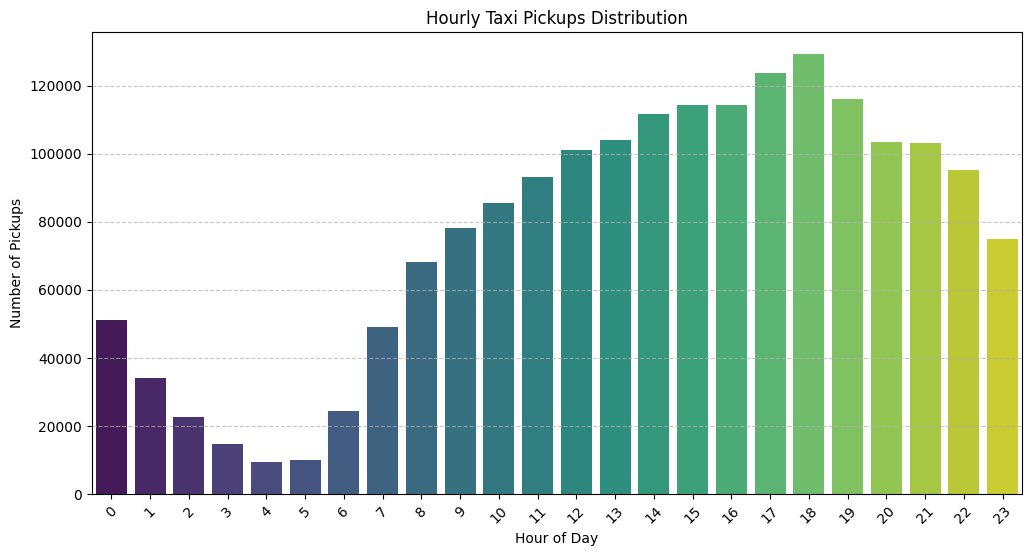

Hourly Pickups:
 pickup_hour
0      51164
1      34280
2      22552
3      14710
4       9437
5      10021
6      24468
7      48991
8      68278
9      78289
10     85630
11     93038
12    101006
13    104108
14    111578
15    114302
16    114294
17    123564
18    129193
19    115923
20    103437
21    103172
22     95162
23     74829
Name: count, dtype: int64


In [26]:
# Extract hour from pickup datetime
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

# Count pickups per hour
hourly_pickups = df['pickup_hour'].value_counts().sort_index()

# Plot the hourly trends
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis')
plt.title('Hourly Taxi Pickups Distribution')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Hourly Pickups:\n", hourly_pickups)

In [ ]:
# Find and show the daily trends in taxi pickups (days of the week)



/tmp/ipykernel_1634/1111705005.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=daily_pickups.index, y=daily_pickups.values, palette='viridis')


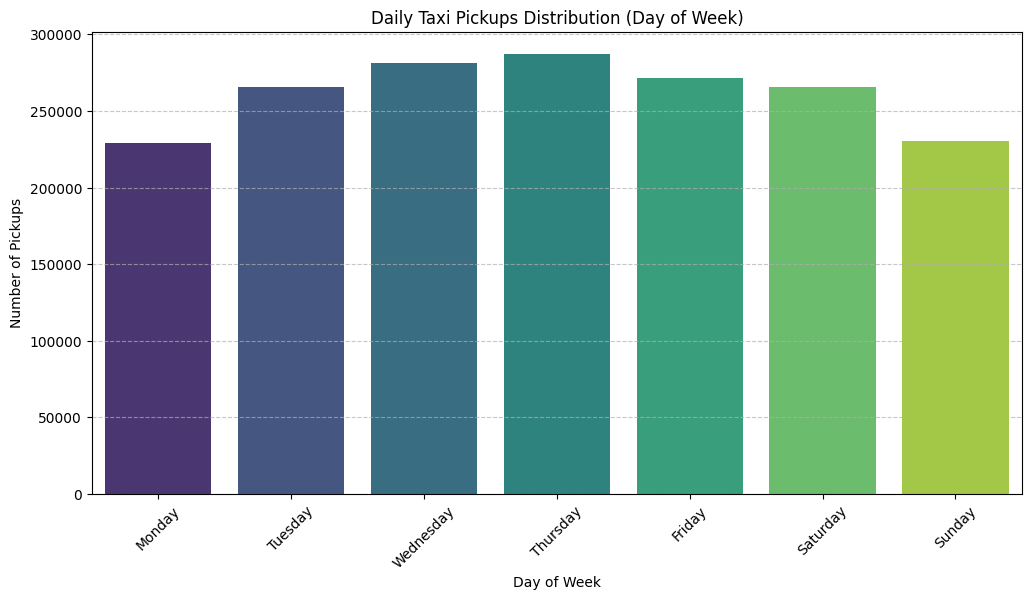

Daily Pickups:
 pickup_day_of_week_name
Monday       228962
Tuesday      265941
Wednesday    281567
Thursday     287271
Friday       271625
Saturday     265862
Sunday       230198
Name: count, dtype: int64


In [27]:
# Extract day of the week from pickup datetime
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.dayofweek

# Map day numbers to names for better readability
day_names = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['pickup_day_of_week_name'] = df['pickup_day_of_week'].map(lambda x: day_names[x])

# Count pickups per day of the week
daily_pickups = df['pickup_day_of_week_name'].value_counts().reindex(day_names)

# Plot the daily trends
plt.figure(figsize=(12, 6))
sns.barplot(x=daily_pickups.index, y=daily_pickups.values, palette='viridis')
plt.title('Daily Taxi Pickups Distribution (Day of Week)')
plt.xlabel('Day of Week')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Daily Pickups:\n", daily_pickups)

/tmp/ipykernel_1634/1640129967.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_pickups.index, y=monthly_pickups.values, palette='viridis')


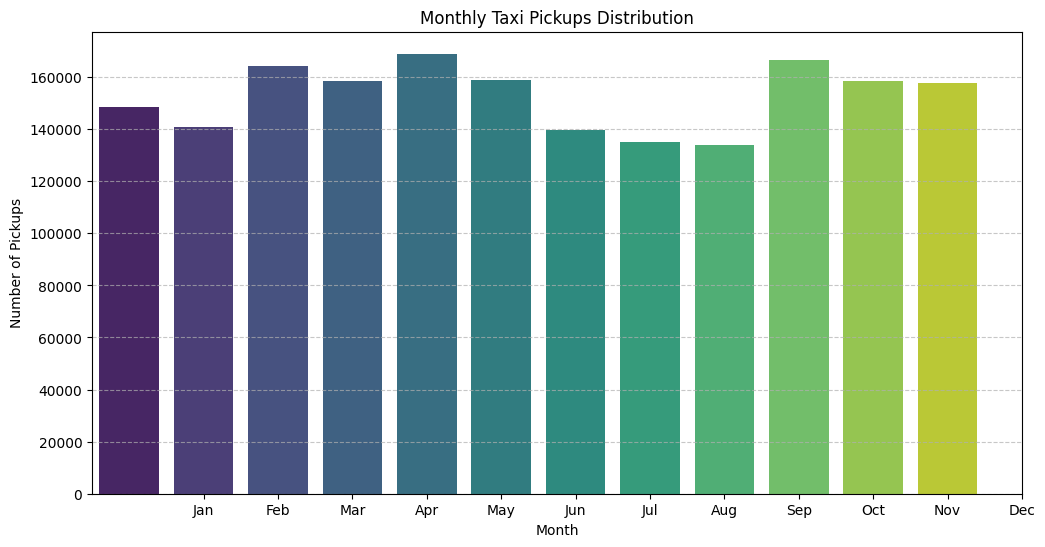

Monthly Pickups:
 pickup_month
1     148476
2     140712
3     164283
4     158378
5     168981
6     158994
7     139728
8     135260
9     133931
10    166525
11    158402
12    157756
Name: count, dtype: int64


In [28]:
# Show the monthly trends in pickups

# Extract month from pickup datetime
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

# Count pickups per month
monthly_pickups = df['pickup_month'].value_counts().sort_index()

# Plot the monthly trends
plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_pickups.index, y=monthly_pickups.values, palette='viridis')
plt.title('Monthly Taxi Pickups Distribution')
plt.xlabel('Month')
plt.ylabel('Number of Pickups')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Monthly Pickups:\n", monthly_pickups)

##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

In [ ]:
# Analyse the above parameters



In [29]:
financial_cols = ['fare_amount', 'tip_amount', 'total_amount', 'trip_distance']

for col in financial_cols:
    negative_count = (df[col] < 0).sum()
    zero_count = (df[col] == 0).sum()

    print(f"Column '{col}':")
    print(f"  Number of negative values: {negative_count}")
    print(f"  Number of zero values: {zero_count}")
    print("\n")

Column 'fare_amount':
  Number of negative values: 0
  Number of zero values: 575


Column 'tip_amount':
  Number of negative values: 0
  Number of zero values: 410262


Column 'total_amount':
  Number of negative values: 74
  Number of zero values: 255


Column 'trip_distance':
  Number of negative values: 0
  Number of zero values: 22962




In [30]:
# Create a DataFrame with non-zero entries for financial parameters
initial_rows = len(df)
df_filtered = df[(df['fare_amount'] != 0) &
                 (df['tip_amount'] != 0) &
                 (df['total_amount'] != 0) &
                 (df['trip_distance'] != 0)].copy()

print(f"Original DataFrame rows: {initial_rows}")
print(f"Filtered DataFrame rows (non-zero financial parameters): {len(df_filtered)}")
print(f"Rows removed: {initial_rows - len(df_filtered)}")

# Display info and head of the filtered DataFrame
df_filtered.info()
display(df_filtered.head())

Original DataFrame rows: 1831426
Filtered DataFrame rows (non-zero financial parameters): 1412905
Rows removed: 418521
<class 'pandas.core.frame.DataFrame'>
Index: 1412905 entries, 0 to 1896397
Data columns (total 23 columns):
 #   Column                   Non-Null Count    Dtype         
---  ------                   --------------    -----         
 0   VendorID                 1412905 non-null  int64         
 1   tpep_pickup_datetime     1412905 non-null  datetime64[us]
 2   tpep_dropoff_datetime    1412905 non-null  datetime64[us]
 3   passenger_count          1412905 non-null  float64       
 4   trip_distance            1412905 non-null  float64       
 5   RatecodeID               1412905 non-null  float64       
 6   store_and_fwd_flag       1412905 non-null  object        
 7   PULocationID             1412905 non-null  int64         
 8   DOLocationID             1412905 non-null  int64         
 9   payment_type             1412905 non-null  int64         
 10  fare_amount 

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_hour,pickup_day_of_week,pickup_day_of_week_name,pickup_month
0,1,2023-04-01 00:58:33,2023-04-01 01:07:03,4.0,1.10,1.0,Y,249,125,1,...,2.70,0.0,1.0,16.30,2.5,0.0,0,5,Saturday,4
2,2,2023-04-01 00:54:11,2023-04-01 01:00:52,1.0,1.53,1.0,N,100,113,1,...,2.86,0.0,1.0,17.16,2.5,0.0,0,5,Saturday,4
3,1,2023-04-01 00:53:11,2023-04-01 01:04:05,2.0,1.50,1.0,N,90,164,1,...,3.40,0.0,1.0,20.50,2.5,0.0,0,5,Saturday,4
5,2,2023-04-01 00:08:28,2023-04-01 00:38:10,2.0,4.78,1.0,N,79,263,1,...,4.98,0.0,1.0,38.18,2.5,0.0,0,5,Saturday,4
6,2,2023-04-01 00:49:46,2023-04-01 00:56:44,1.0,1.57,1.0,N,249,100,1,...,2.86,0.0,1.0,17.16,2.5,0.0,0,5,Saturday,4


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [ ]:
# Create a df with non zero entries for the selected parameters.



**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [ ]:
# Group data by month and analyse monthly revenue



/tmp/ipykernel_1634/3901423910.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')


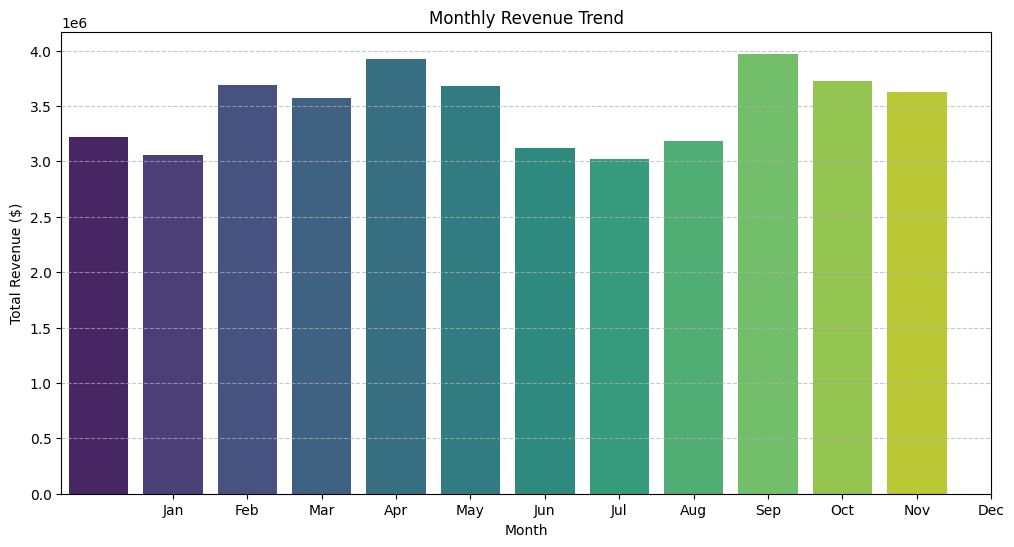

Monthly Revenue:


,total_amount
pickup_month,
1,3216268.43
2,3059834.43
3,3687542.14
4,3571705.91
5,3927809.27
6,3678632.41
7,3118144.43
8,3016976.09
9,3186213.26


In [31]:
monthly_revenue = df_filtered.groupby('pickup_month')['total_amount'].sum()

plt.figure(figsize=(12, 6))
sns.barplot(x=monthly_revenue.index, y=monthly_revenue.values, palette='viridis')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue ($)')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Monthly Revenue:")
display(monthly_revenue)

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [ ]:
# Calculate proportion of each quarter



In [32]:
# Define quarters based on months
def get_quarter(month):
    if month in [1, 2, 3]:
        return 'Q1'
    elif month in [4, 5, 6]:
        return 'Q2'
    elif month in [7, 8, 9]:
        return 'Q3'
    else:
        return 'Q4'

df_filtered['quarter'] = df_filtered['pickup_month'].apply(get_quarter)

# Calculate total revenue per quarter
quarterly_revenue = df_filtered.groupby('quarter')['total_amount'].sum()

# Calculate total annual revenue
total_annual_revenue = quarterly_revenue.sum()

# Calculate proportion of each quarter in the total revenue
quarterly_revenue_proportion = (quarterly_revenue / total_annual_revenue) * 100

print("Quarterly Revenue:")
display(quarterly_revenue)
print("\nProportion of each quarter in total revenue (%):")
display(quarterly_revenue_proportion.sort_index())

Quarterly Revenue:


,total_amount
quarter,
Q1,9963645.00
Q2,11178147.59
Q3,9321333.78
Q4,11328341.54



Proportion of each quarter in total revenue (%):


,total_amount
quarter,
Q1,23.841338
Q2,26.747439
Q3,22.304394
Q4,27.106829


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

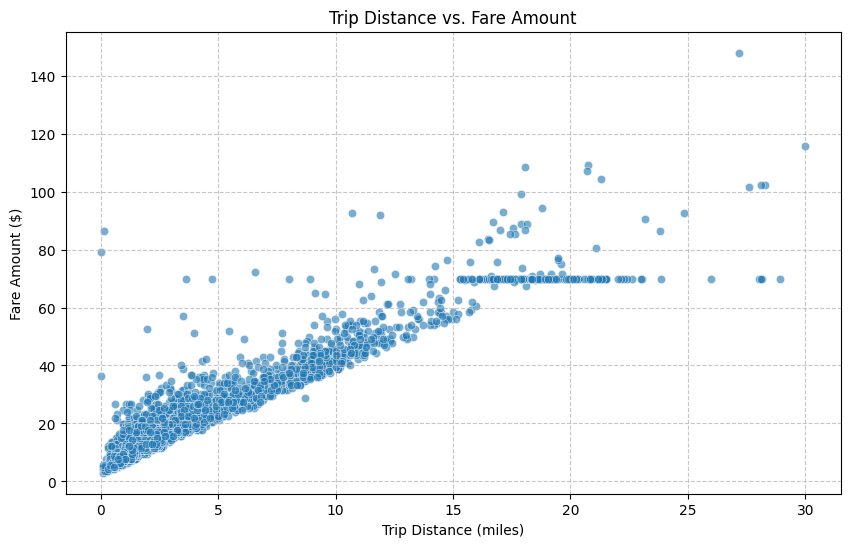

Correlation between trip_distance and fare_amount: 0.9497


In [33]:
# Show how trip fare is affected by distance
# Visualize the relationship between trip_distance and fare_amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='fare_amount', data=df_filtered.sample(n=5000, random_state=42), alpha=0.6)
plt.title('Trip Distance vs. Fare Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calculate the correlation between trip_distance and fare_amount
correlation = df_filtered['trip_distance'].corr(df_filtered['fare_amount'])
print(f"Correlation between trip_distance and fare_amount: {correlation:.4f}")


**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

In [ ]:
# Show relationship between fare and trip duration



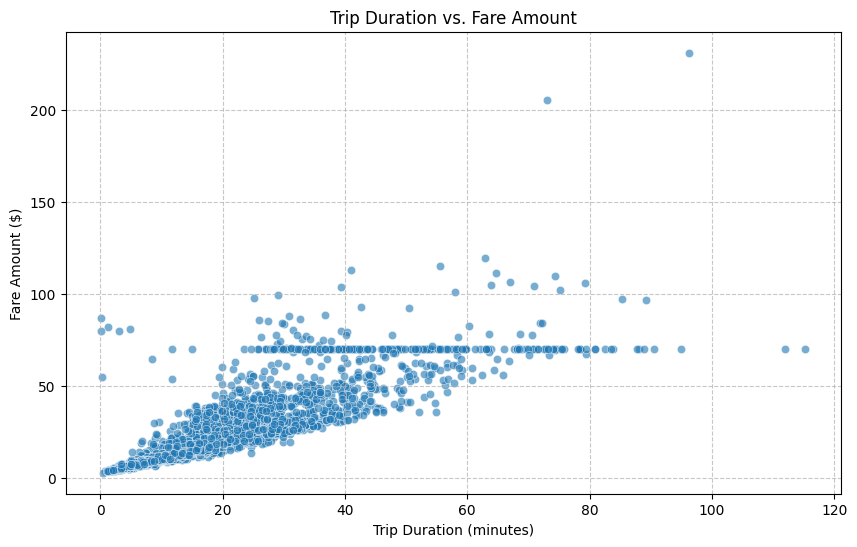

Correlation between trip_duration and fare_amount: 0.8611


In [34]:
# Calculate trip duration in minutes
df_filtered['trip_duration_minutes'] = (df_filtered['tpep_dropoff_datetime'] - df_filtered['tpep_pickup_datetime']).dt.total_seconds() / 60

# Filter out trips with unrealistic durations (e.g., less than 1 minute or extremely long)
df_filtered_duration = df_filtered[(df_filtered['trip_duration_minutes'] > 0) & (df_filtered['trip_duration_minutes'] < 240)].copy()

# Visualize the relationship between trip_duration and fare_amount
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_duration_minutes', y='fare_amount', data=df_filtered_duration.sample(n=5000, random_state=42), alpha=0.6)
plt.title('Trip Duration vs. Fare Amount')
plt.xlabel('Trip Duration (minutes)')
plt.ylabel('Fare Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calculate the correlation between trip_duration and fare_amount
correlation_duration_fare = df_filtered_duration['trip_duration_minutes'].corr(df_filtered_duration['fare_amount'])
print(f"Correlation between trip_duration and fare_amount: {correlation_duration_fare:.4f}")

In [ ]:
# Show relationship between fare and number of passengers



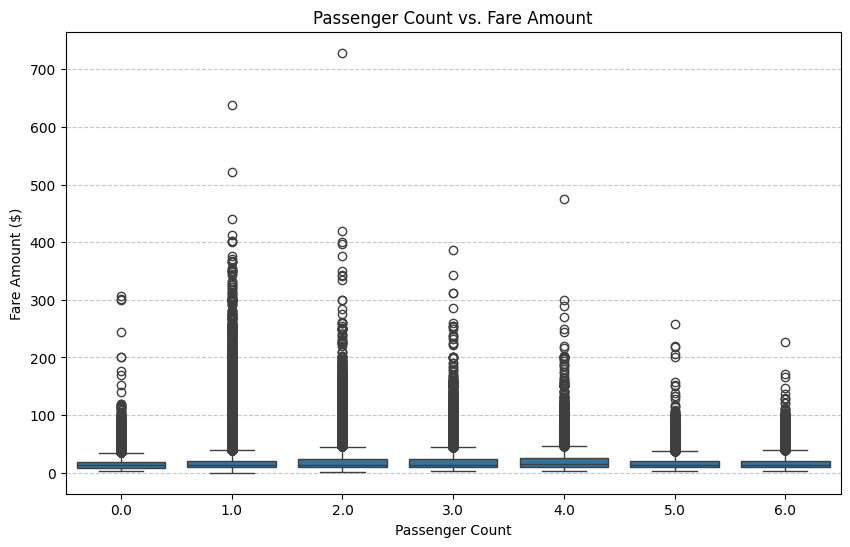

Correlation between passenger_count and fare_amount: 0.0403


In [35]:
# Visualize the relationship between passenger_count and fare_amount
plt.figure(figsize=(10, 6))
sns.boxplot(x='passenger_count', y='fare_amount', data=df_filtered)
plt.title('Passenger Count vs. Fare Amount')
plt.xlabel('Passenger Count')
plt.ylabel('Fare Amount ($)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Calculate the correlation between passenger_count and fare_amount
correlation_passenger_fare = df_filtered['passenger_count'].corr(df_filtered['fare_amount'])
print(f"Correlation between passenger_count and fare_amount: {correlation_passenger_fare:.4f}")

In [ ]:
# Show relationship between tip and trip distance



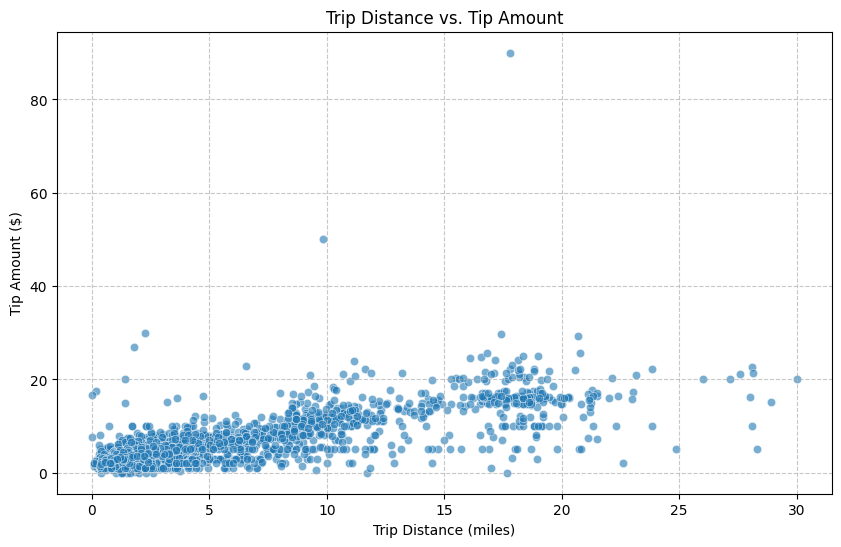

Correlation between trip_distance and tip_amount: 0.7991


In [36]:
# Visualize the relationship between tip_amount and trip_distance
plt.figure(figsize=(10, 6))
sns.scatterplot(x='trip_distance', y='tip_amount', data=df_filtered.sample(n=5000, random_state=42), alpha=0.6)
plt.title('Trip Distance vs. Tip Amount')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Tip Amount ($)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Calculate the correlation between trip_distance and tip_amount
correlation_distance_tip = df_filtered['trip_distance'].corr(df_filtered['tip_amount'])
print(f"Correlation between trip_distance and tip_amount: {correlation_distance_tip:.4f}")

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

In [ ]:
# Analyse the distribution of different payment types (payment_type).




/tmp/ipykernel_1634/258843931.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_type_labels, y=payment_type_counts.values, palette='viridis')


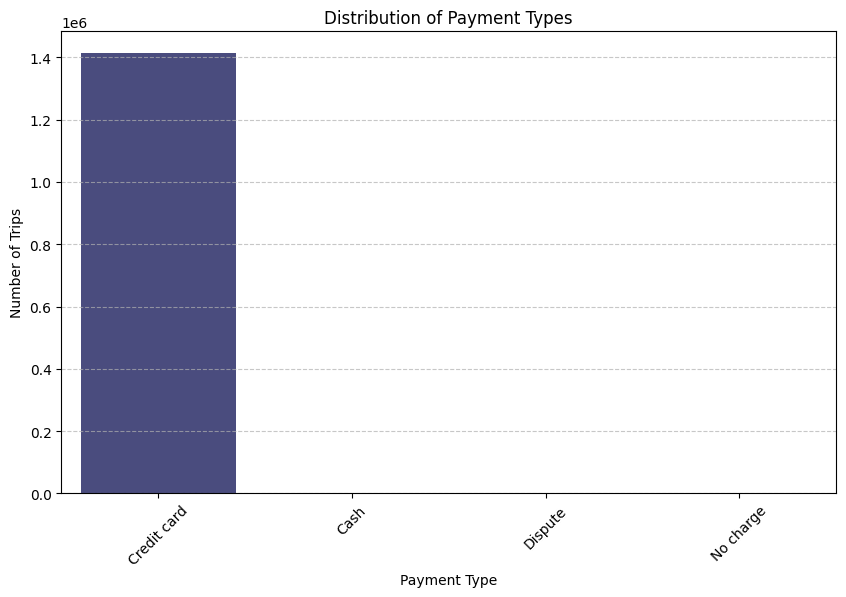

Distribution of Payment Types:


,count
payment_type,
Credit card,1412859
Cash,23
Dispute,16
No charge,7


In [37]:
# Count the occurrences of each payment type
payment_type_counts = df_filtered['payment_type'].value_counts()

# Map payment type codes to their descriptions for better readability
payment_type_map = {
    1: 'Credit card',
    2: 'Cash',
    3: 'No charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided trip'
}
payment_type_labels = payment_type_counts.index.map(payment_type_map)

# Plot the distribution of payment types
plt.figure(figsize=(10, 6))
sns.barplot(x=payment_type_labels, y=payment_type_counts.values, palette='viridis')
plt.title('Distribution of Payment Types')
plt.xlabel('Payment Type')
plt.ylabel('Number of Trips')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Distribution of Payment Types:")
display(payment_type_counts.rename(index=payment_type_map))

- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [ ]:
# !pip install geopandas
!pip install geopandas

**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [38]:
import geopandas as gpd

# Read the shapefile using geopandas
zones = gpd.read_file('/content/drive/MyDrive/Taxi_Zones/taxi_zones.shp')
zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

In [ ]:
# print(zones.info())

# zones.plot()


In [39]:
print(zones.info())

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


<Axes: >

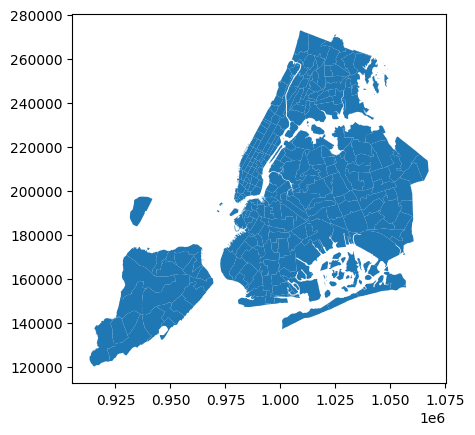

In [40]:
zones.plot()

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [ ]:
# Merge zones and trip records using locationID and PULocationID



In [41]:
import pandas as pd
df_merged = pd.merge(df_filtered, zones, left_on='PULocationID', right_on='LocationID', how='left')
display(df_merged.head())

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_month,quarter,trip_duration_minutes,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,2023-04-01 00:58:33,2023-04-01 01:07:03,4.0,1.10,1.0,Y,249,125,1,...,4,Q2,8.500000,249.0,0.036384,0.000072,West Village,249.0,Manhattan,"POLYGON ((983555.319 204876.901, 983469.158 20..."
1,2,2023-04-01 00:54:11,2023-04-01 01:00:52,1.0,1.53,1.0,N,100,113,1,...,4,Q2,6.683333,100.0,0.024813,0.000037,Garment District,100.0,Manhattan,"POLYGON ((987770.527 212686.678, 987638.873 21..."
2,1,2023-04-01 00:53:11,2023-04-01 01:04:05,2.0,1.50,1.0,N,90,164,1,...,4,Q2,10.900000,90.0,0.030759,0.000055,Flatiron,90.0,Manhattan,"POLYGON ((985265.129 208165.863, 985125.733 20..."
3,2,2023-04-01 00:08:28,2023-04-01 00:38:10,2.0,4.78,1.0,N,79,263,1,...,4,Q2,29.700000,79.0,0.042625,0.000108,East Village,79.0,Manhattan,"POLYGON ((988746.067 202151.955, 988733.885 20..."
4,2,2023-04-01 00:49:46,2023-04-01 00:56:44,1.0,1.57,1.0,N,249,100,1,...,4,Q2,6.966667,249.0,0.036384,0.000072,West Village,249.0,Manhattan,"POLYGON ((983555.319 204876.901, 983469.158 20..."


In [42]:
trips_per_zone = df_merged['PULocationID'].value_counts().reset_index()
trips_per_zone.columns = ['PULocationID', 'trip_count']
display(trips_per_zone.head())

,PULocationID,trip_count
0,237,69858
1,161,67730
2,236,63695
3,132,63639
4,162,52690


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID

In [ ]:
# Group data by location and calculate the number of trips



**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [ ]:
# Merge trip counts back to the zones GeoDataFrame




In [43]:
zones_with_trips = zones.merge(trips_per_zone, left_on='LocationID', right_on='PULocationID', how='left')
# Fill NaN values in 'trip_count' with 0 for zones with no recorded trips
zones_with_trips['trip_count'] = zones_with_trips['trip_count'].fillna(0)
display(zones_with_trips.head())

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,35.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",NaN,0.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,1403.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",NaN,0.0


The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

In [ ]:
# Define figure and axis


# Plot the map and display it



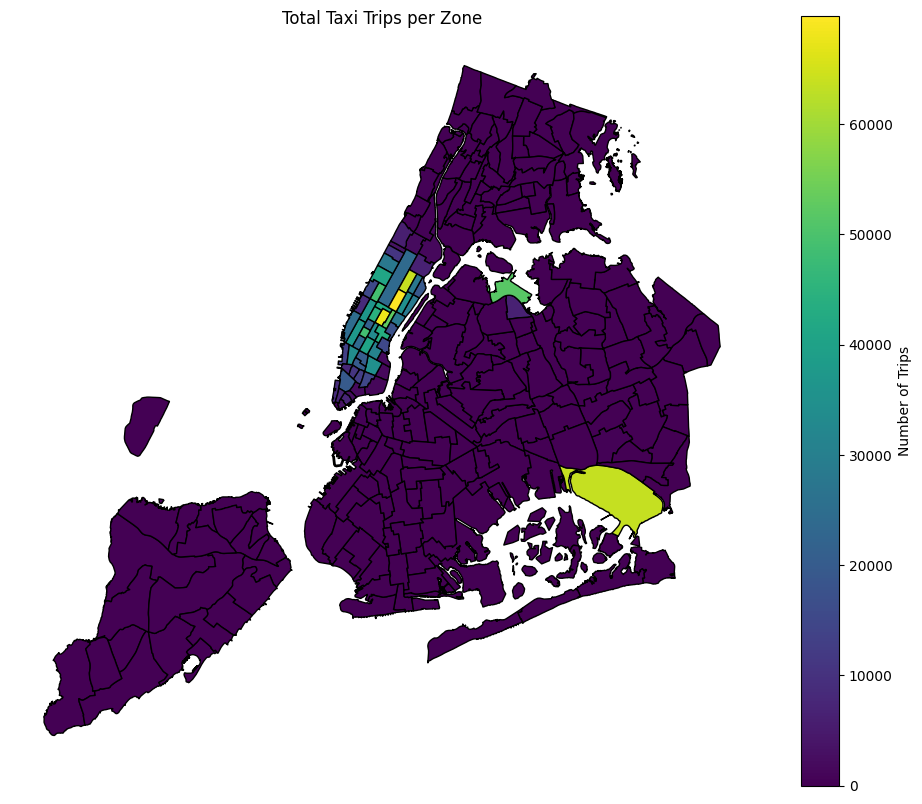

In [44]:
fig, ax = plt.subplots(1, 1, figsize=(12, 10))

zones_with_trips.plot(
    column='trip_count',
    ax=ax,
    legend=True,
    cmap='viridis', # Choose a colormap
    legend_kwds={'label': 'Number of Trips', 'orientation': 'vertical'},
    edgecolor='black'
)
ax.set_title('Total Taxi Trips per Zone')
ax.set_axis_off() # Turn off the axis for a cleaner map
plt.show()


In [ ]:
# can you try displaying the zones DF sorted by the number of trips?



Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

In [ ]:
# Find routes which have the slowest speeds at different times of the day



In [45]:
# Calculate trip duration in hours
df_filtered['trip_duration_hours'] = (df_filtered['tpep_dropoff_datetime'] - df_filtered['tpep_pickup_datetime']).dt.total_seconds() / 3600

# Filter out trips with zero or negative duration to avoid division by zero or unrealistic speeds
df_routes = df_filtered[df_filtered['trip_duration_hours'] > 0].copy()

# Group by pickup location, dropoff location, and pickup hour to calculate average speed
slow_routes = df_routes.groupby(['PULocationID', 'DOLocationID', 'pickup_hour']).agg(
    avg_trip_distance=('trip_distance', 'mean'),
    avg_trip_duration_hours=('trip_duration_hours', 'mean')
).reset_index()

# Calculate average speed in MPH
slow_routes['average_speed_mph'] = slow_routes['avg_trip_distance'] / slow_routes['avg_trip_duration_hours']

# Merge with zones to get human-readable location names for PULocationID
slow_routes = pd.merge(slow_routes, zones[['LocationID', 'zone']], left_on='PULocationID', right_on='LocationID', how='left')
slow_routes = slow_routes.rename(columns={'zone': 'pickup_zone'})
slow_routes = slow_routes.drop(columns=['LocationID'])

# Merge with zones again to get human-readable location names for DOLocationID
slow_routes = pd.merge(slow_routes, zones[['LocationID', 'zone']], left_on='DOLocationID', right_on='LocationID', how='left')
slow_routes = slow_routes.rename(columns={'zone': 'dropoff_zone'})
slow_routes = slow_routes.drop(columns=['LocationID'])

# Sort to find the slowest routes
slowest_routes_by_hour = slow_routes.sort_values(by='average_speed_mph').head(10)

print("Top 10 slowest routes by average speed (MPH):")
display( slowest_routes_by_hour)

Top 10 slowest routes by average speed (MPH):


,PULocationID,DOLocationID,pickup_hour,avg_trip_distance,avg_trip_duration_hours,average_speed_mph,pickup_zone,dropoff_zone
93023,243,264,17,0.180000,23.159167,0.007772,Washington Heights North,NaN
6803,45,45,10,0.050000,0.840556,0.059484,Chinatown,Chinatown
61078,162,162,4,1.540000,23.772778,0.064780,Midtown East,Midtown East
2282,13,209,7,0.860000,11.829028,0.072703,Battery Park City,Seaport
54738,151,24,1,0.477500,6.025972,0.079240,Manhattan Valley,Bloomingdale
15127,70,138,6,1.490000,17.376111,0.085750,East Elmhurst,LaGuardia Airport
75245,224,113,20,0.796667,8.039630,0.099092,Stuy Town/Peter Cooper Village,Greenwich Village North
89602,237,238,4,2.850000,23.675833,0.120376,Upper East Side South,Upper West Side North
8941,48,184,1,0.140000,1.094444,0.127919,Clinton East,Pelham Bay Park
67719,170,125,2,3.070000,23.333056,0.131573,Murray Hill,Hudson Sq


How does identifying high-traffic, high-demand routes help us?

**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

/tmp/ipykernel_1634/4238505820.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis')


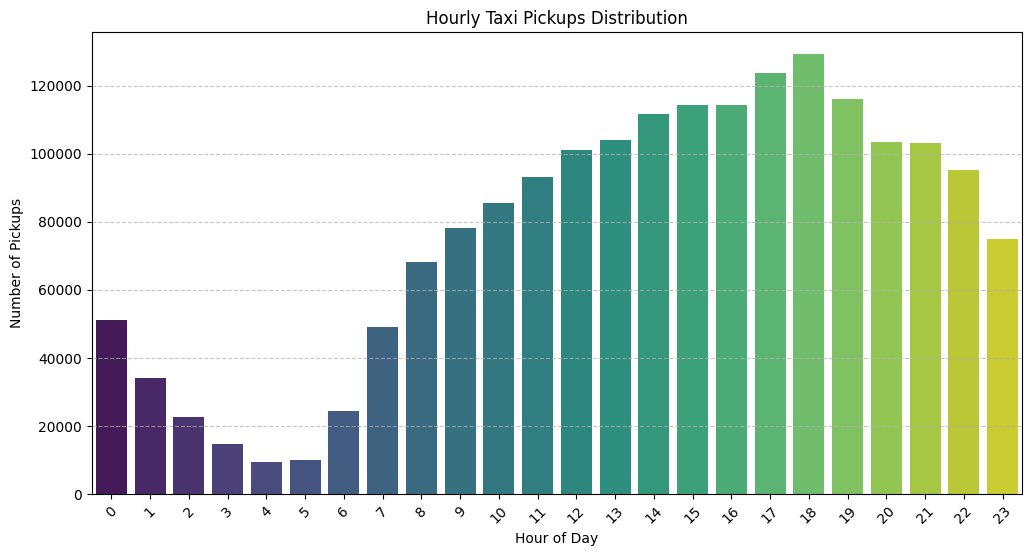

The busiest hour for taxi pickups is 18:00 with 129193 sampled trips.


In [46]:
# Visualise the number of trips per hour and find the busiest hour

# Calculate the number of trips at each hour of the day
# 'hourly_pickups' was already calculated in a previous step

# Plot the hourly trends
plt.figure(figsize=(12, 6))
sns.barplot(x=hourly_pickups.index, y=hourly_pickups.values, palette='viridis')
plt.title('Hourly Taxi Pickups Distribution')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Find the busiest hour
busiest_hour = hourly_pickups.idxmax()
max_pickups = hourly_pickups.max()

print(f"The busiest hour for taxi pickups is {busiest_hour}:00 with {max_pickups} sampled trips.")

In [47]:
# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05 # Assuming a 5% sampling rate as per earlier instructions

# Calculate the actual number of trips for the busiest hour
actual_max_pickups = max_pickups / sample_fraction

print(f"Scaled up, the busiest hour ({busiest_hour}:00) has an estimated {actual_max_pickups:,.0f} actual trips.")

# Find the five busiest hours and scale them up
top_5_busiest_hours = hourly_pickups.nlargest(5)
actual_top_5_busiest_hours = top_5_busiest_hours / sample_fraction

print("\nEstimated actual trips for the five busiest hours:")
display(actual_top_5_busiest_hours)

Scaled up, the busiest hour (18:00) has an estimated 2,583,860 actual trips.

Estimated actual trips for the five busiest hours:


,count
pickup_hour,
18,2583860.0
17,2471280.0
19,2318460.0
15,2286040.0
16,2285880.0


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [48]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05 # Already defined, but setting it explicitly for this step

# Find the five busiest hours (already calculated previously)
# top_5_busiest_hours = hourly_pickups.nlargest(5)

# Calculate the actual number of trips for the five busiest hours
actual_top_5_busiest_hours_calculated = top_5_busiest_hours / sample_fraction

print("Estimated actual trips for the five busiest hours:")
display(actual_top_5_busiest_hours_calculated)

Estimated actual trips for the five busiest hours:


,count
pickup_hour,
18,2583860.0
17,2471280.0
19,2318460.0
15,2286040.0
16,2285880.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

In [ ]:
# Compare traffic trends for the week days and weekends



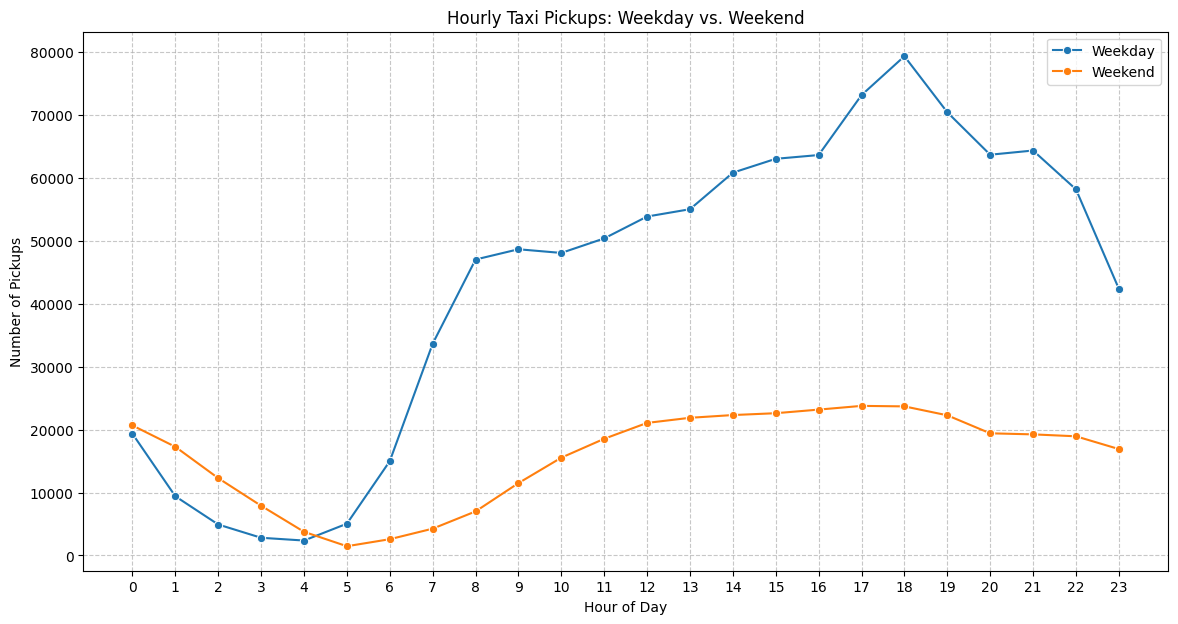

Hourly Traffic Patterns (Weekday vs. Weekend):


pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
day_type,,,,,,,,,,,,,,,,,,,,,
Weekday,19338,9401,4914,2807,2366,5042,14990,33655,47043,48673,...,60848,63055,63652,73179,79363,70454,63704,64371,58205,42398
Weekend,20659,17267,12284,7894,3756,1463,2579,4253,6996,11495,...,22316,22610,23182,23774,23695,22276,19414,19244,18940,16910


In [49]:
# Create a 'day_type' column (Weekday/Weekend)
df_filtered['day_type'] = df_filtered['pickup_day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

# Group by day_type and pickup_hour to get trip counts
hourly_traffic_by_day_type = df_filtered.groupby(['day_type', 'pickup_hour']).size().unstack(fill_value=0)

# Plot the hourly traffic patterns for weekdays and weekends
plt.figure(figsize=(14, 7))

sns.lineplot(x=hourly_traffic_by_day_type.columns, y=hourly_traffic_by_day_type.loc['Weekday'], label='Weekday', marker='o')
sns.lineplot(x=hourly_traffic_by_day_type.columns, y=hourly_traffic_by_day_type.loc['Weekend'], label='Weekend', marker='o')

plt.title('Hourly Taxi Pickups: Weekday vs. Weekend')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24)) # Ensure all hours are displayed
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

print("Hourly Traffic Patterns (Weekday vs. Weekend):")
display(hourly_traffic_by_day_type)

What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

In [ ]:
# Find top 10 pickup and dropoff zones



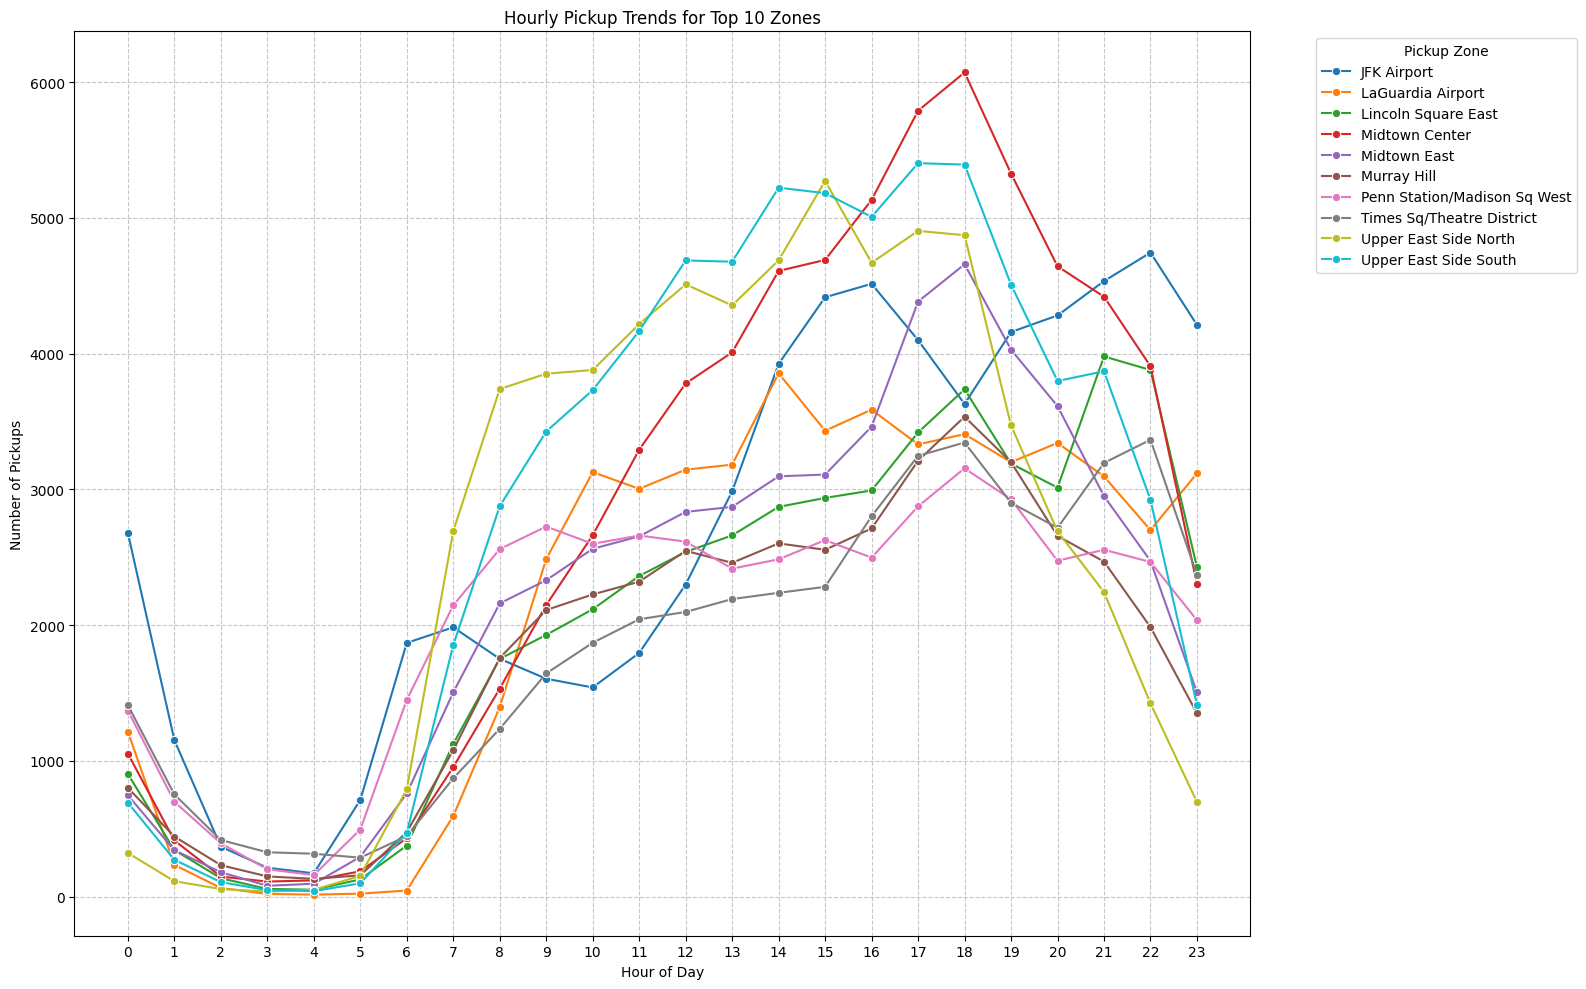

Hourly Pickup Trends for Top 10 Zones:


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
zone,,,,,,,,,,,,,,,,,,,,,
JFK Airport,2680,1153,368,213,172,712,1869,1984,1752,1605,...,3924,4415,4514,4099,3629,4159,4281,4534,4744,4211
LaGuardia Airport,1216,234,64,20,15,22,45,594,1396,2486,...,3855,3432,3587,3331,3407,3200,3342,3095,2700,3118
Lincoln Square East,904,343,136,57,51,127,376,1125,1751,1928,...,2871,2937,2992,3419,3737,3190,3013,3979,3879,2427
Midtown Center,1054,414,148,111,120,187,431,954,1532,2148,...,4609,4690,5132,5789,6071,5326,4643,4419,3907,2302
Midtown East,747,342,180,80,95,293,760,1504,2160,2331,...,3096,3109,3462,4383,4658,4029,3613,2950,2473,1504


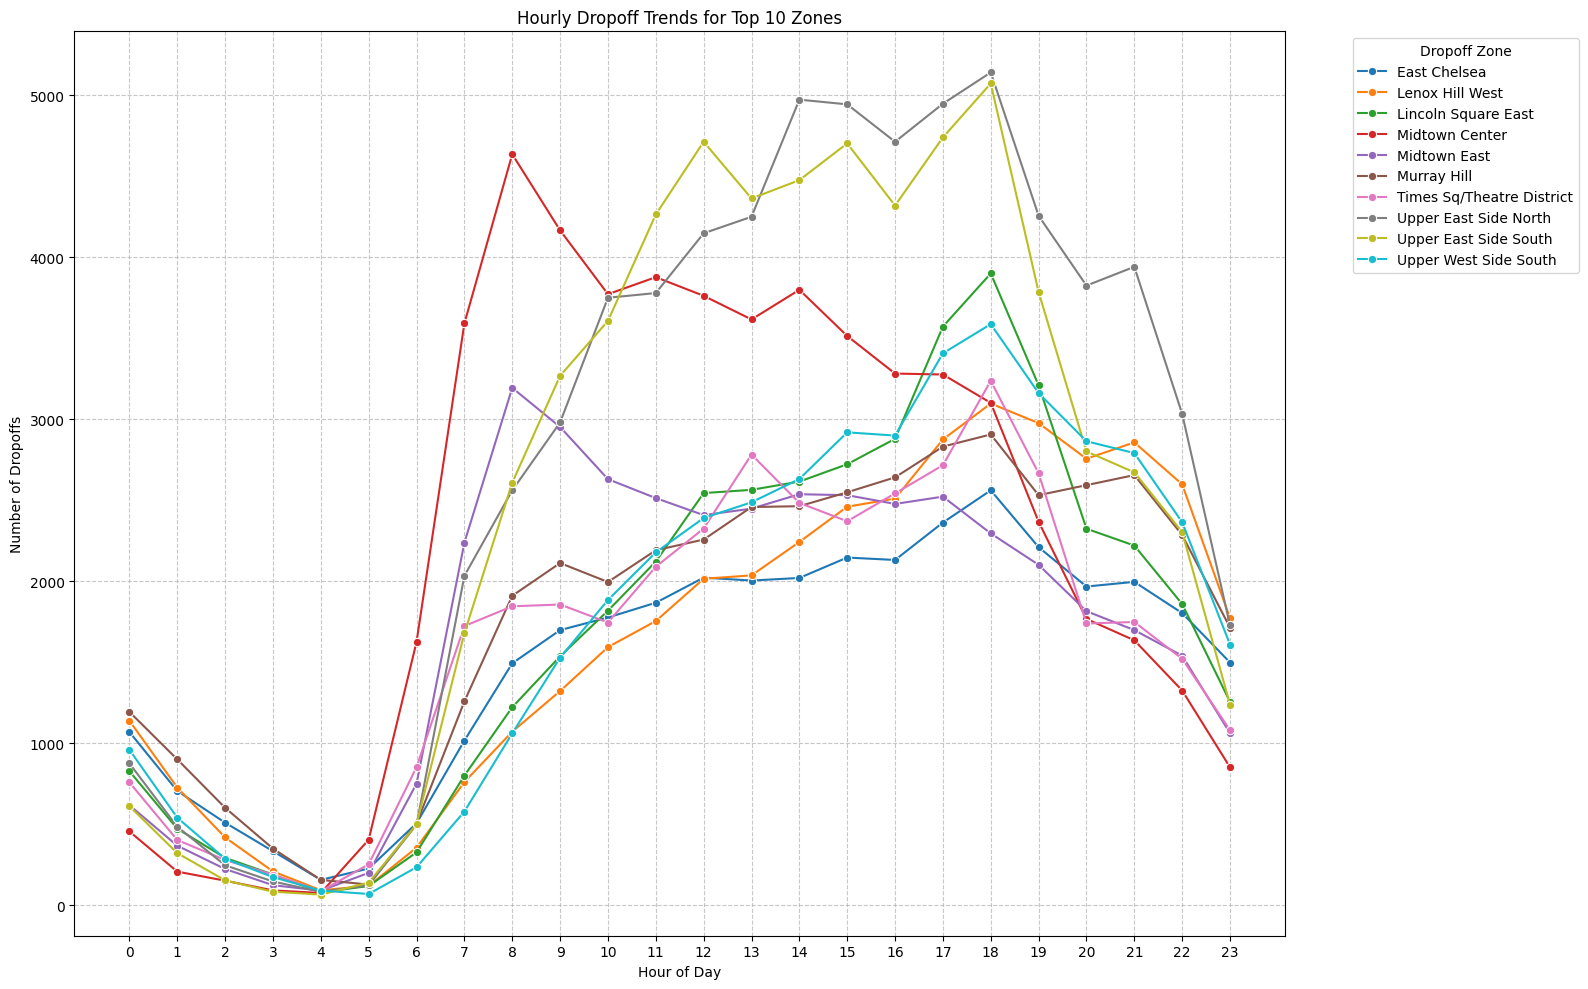

Hourly Dropoff Trends for Top 10 Zones:


,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
zone,,,,,,,,,,,,,,,,,,,,,
East Chelsea,1070,706,510,334,157,227,506,1017,1494,1699,...,2021,2147,2132,2363,2562,2211,1968,1997,1804,1499
Lenox Hill West,1139,727,419,209,93,120,356,761,1072,1323,...,2243,2461,2511,2876,3098,2977,2757,2858,2599,1773
Lincoln Square East,828,473,293,190,80,119,327,801,1223,1537,...,2616,2723,2880,3573,3901,3210,2325,2221,1860,1256
Midtown Center,456,208,152,92,76,405,1626,3593,4637,4167,...,3800,3515,3283,3277,3102,2368,1768,1636,1326,852
Midtown East,618,368,224,124,91,200,751,2239,3195,2953,...,2538,2532,2478,2523,2296,2102,1816,1699,1541,1062


In [50]:
# Identify top 10 pickup zones
top_10_pickup_zones_id = df_filtered['PULocationID'].value_counts().nlargest(10).index
top_10_pickup_zones_data = df_filtered[df_filtered['PULocationID'].isin(top_10_pickup_zones_id)]

# Calculate hourly pickups for top 10 zones
hourly_pickups_top_zones = top_10_pickup_zones_data.groupby(['PULocationID', 'pickup_hour']).size().unstack(fill_value=0)

# Merge with zones to get names
hourly_pickups_top_zones = hourly_pickups_top_zones.merge(zones[['LocationID', 'zone']], left_index=True, right_on='LocationID', how='left')
hourly_pickups_top_zones = hourly_pickups_top_zones.set_index('zone').drop(columns='LocationID')

# Plot hourly pickup trends for top 10 zones
plt.figure(figsize=(16, 10))
for zone_name in hourly_pickups_top_zones.index:
    sns.lineplot(x=hourly_pickups_top_zones.columns, y=hourly_pickups_top_zones.loc[zone_name], label=zone_name, marker='o')

plt.title('Hourly Pickup Trends for Top 10 Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Pickups')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Pickup Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Hourly Pickup Trends for Top 10 Zones:")
display(hourly_pickups_top_zones.head())

# Identify top 10 dropoff zones
top_10_dropoff_zones_id = df_filtered['DOLocationID'].value_counts().nlargest(10).index
top_10_dropoff_zones_data = df_filtered[df_filtered['DOLocationID'].isin(top_10_dropoff_zones_id)]

# Calculate hourly dropoffs for top 10 zones
hourly_dropoffs_top_zones = top_10_dropoff_zones_data.groupby(['DOLocationID', 'pickup_hour']).size().unstack(fill_value=0)

# Merge with zones to get names
hourly_dropoffs_top_zones = hourly_dropoffs_top_zones.merge(zones[['LocationID', 'zone']], left_index=True, right_on='LocationID', how='left')
hourly_dropoffs_top_zones = hourly_dropoffs_top_zones.set_index('zone').drop(columns='LocationID')

# Plot hourly dropoff trends for top 10 zones
plt.figure(figsize=(16, 10))
for zone_name in hourly_dropoffs_top_zones.index:
    sns.lineplot(x=hourly_dropoffs_top_zones.columns, y=hourly_dropoffs_top_zones.loc[zone_name], label=zone_name, marker='o')

plt.title('Hourly Dropoff Trends for Top 10 Zones')
plt.xlabel('Hour of Day')
plt.ylabel('Number of Dropoffs')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Dropoff Zone', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("Hourly Dropoff Trends for Top 10 Zones:")
display(hourly_dropoffs_top_zones.head())

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [ ]:
# Find the top 10 and bottom 10 pickup/dropoff ratios



In [51]:
# Calculate total pickups per zone
pickup_counts = df_filtered['PULocationID'].value_counts().reset_index()
pickup_counts.columns = ['LocationID', 'pickup_count']

# Calculate total dropoffs per zone
dropoff_counts = df_filtered['DOLocationID'].value_counts().reset_index()
dropoff_counts.columns = ['LocationID', 'dropoff_count']

# Merge pickup and dropoff counts with zone information
zone_ratios = zones.merge(pickup_counts, on='LocationID', how='left')
zone_ratios = zone_ratios.merge(dropoff_counts, on='LocationID', how='left')

# Fill NaN counts with 0 (for zones with no pickups or dropoffs)
zone_ratios['pickup_count'] = zone_ratios['pickup_count'].fillna(0)
zone_ratios['dropoff_count'] = zone_ratios['dropoff_count'].fillna(0)

# Calculate pickup/dropoff ratio, handling division by zero
# Add a small epsilon to dropoff_count to avoid division by zero for zones with 0 dropoffs
epsilon = 1e-6
zone_ratios['pickup_dropoff_ratio'] = zone_ratios['pickup_count'] / (zone_ratios['dropoff_count'] + epsilon)

# Sort by ratio to find top 10 highest and bottom 10 lowest
top_10_ratios = zone_ratios.sort_values(by='pickup_dropoff_ratio', ascending=False).head(10)
bottom_10_ratios = zone_ratios.sort_values(by='pickup_dropoff_ratio', ascending=True).head(10)

print("Top 10 Zones by Pickup/Dropoff Ratio:")
display(top_10_ratios[['zone', 'pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']])

print("\nBottom 10 Zones by Pickup/Dropoff Ratio:")
display(bottom_10_ratios[['zone', 'pickup_count', 'dropoff_count', 'pickup_dropoff_ratio']])

Top 10 Zones by Pickup/Dropoff Ratio:


,zone,pickup_count,dropoff_count,pickup_dropoff_ratio
1,Jamaica Bay,2.0,0.0,2.000000e+06
198,Rikers Island,2.0,0.0,2.000000e+06
69,East Elmhurst,6402.0,462.0,1.385714e+01
131,JFK Airport,63639.0,13430.0,4.738570e+00
137,LaGuardia Airport,51617.0,17977.0,2.871280e+00
206,Saint Michaels Cemetery/Woodside,12.0,7.0,1.714285e+00
185,Penn Station/Madison Sq West,48583.0,29442.0,1.650126e+00
42,Central Park,23917.0,17235.0,1.387699e+00
113,Greenwich Village South,19825.0,14340.0,1.382497e+00
248,West Village,33898.0,25470.0,1.330899e+00



Bottom 10 Zones by Pickup/Dropoff Ratio:


,zone,pickup_count,dropoff_count,pickup_dropoff_ratio
244,West Brighton,0.0,20.0,0.0
116,Hammels/Arverne,0.0,54.0,0.0
114,Grymes Hill/Clifton,0.0,17.0,0.0
109,Great Kills Park,0.0,0.0,0.0
26,Breezy Point/Fort Tilden/Riis Beach,0.0,21.0,0.0
108,Great Kills,0.0,15.0,0.0
104,Governor's Island/Ellis Island/Liberty Island,0.0,0.0,0.0
29,Broad Channel,0.0,7.0,0.0
103,Governor's Island/Ellis Island/Liberty Island,0.0,0.0,0.0
31,Bronxdale,0.0,35.0,0.0


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [ ]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Note that the top zones should be of night hours and not the overall top zones



In [53]:
night_hours_df = df_filtered[((df_filtered['pickup_hour'] >= 23) | (df_filtered['pickup_hour'] <= 5))].copy()

# Top 10 pickup zones during night hours
night_pickup_counts = night_hours_df['PULocationID'].value_counts().nlargest(10).reset_index()
night_pickup_counts.columns = ['LocationID', 'night_pickup_count']
top_10_night_pickups = zones.merge(night_pickup_counts, on='LocationID', how='inner')

print("\nTop 10 Pickup Zones during Night Hours (11 PM - 5 AM):")
display(top_10_night_pickups[['zone', 'night_pickup_count']])

# Top 10 dropoff zones during night hours
night_dropoff_counts = night_hours_df['DOLocationID'].value_counts().nlargest(10).reset_index()
night_dropoff_counts.columns = ['LocationID', 'night_dropoff_count']
top_10_night_dropoffs = zones.merge(night_dropoff_counts, on='LocationID', how='inner')

print("\nTop 10 Dropoff Zones during Night Hours (11 PM - 5 AM):")
display(top_10_night_dropoffs[['zone', 'night_dropoff_count']])


Top 10 Pickup Zones during Night Hours (11 PM - 5 AM):


,zone,night_pickup_count
0,Clinton East,8060
1,East Village,12843
2,Greenwich Village South,7285
3,JFK Airport,9509
4,LaGuardia Airport,4689
5,Lower East Side,8005
6,Midtown South,4786
7,Penn Station/Madison Sq West,5354
8,Times Sq/Theatre District,5881
9,West Village,10494



Top 10 Dropoff Zones during Night Hours (11 PM - 5 AM):


,zone,night_dropoff_count
0,Clinton East,5106
1,East Chelsea,4503
2,East Village,6754
3,Gramercy,4851
4,Lenox Hill West,4480
5,Murray Hill,5046
6,Upper East Side North,3690
7,Upper West Side South,3733
8,West Village,4133
9,Yorkville West,4231


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [ ]:
# Filter for night hours (11 PM to 5 AM)



In [54]:
night_revenue = night_hours_df['total_amount'].sum()

day_hours_df = df_filtered[~((df_filtered['pickup_hour'] >= 23) | (df_filtered['pickup_hour'] <= 5))].copy()
day_revenue = day_hours_df['total_amount'].sum()

total_revenue = df_filtered['total_amount'].sum()

night_revenue_share = (night_revenue / total_revenue) * 100
day_revenue_share = (day_revenue / total_revenue) * 100

print(f"Total Revenue during Night Hours (11 PM - 5 AM): ${night_revenue:,.2f}")
print(f"Share of Night Hours Revenue: {night_revenue_share:,.2f}%")
print(f"\nTotal Revenue during Day Hours (6 AM - 10 PM): ${day_revenue:,.2f}")
print(f"Share of Day Hours Revenue: {day_revenue_share:,.2f}%")

Total Revenue during Night Hours (11 PM - 5 AM): $4,987,060.27
Share of Night Hours Revenue: 11.93%

Total Revenue during Day Hours (6 AM - 10 PM): $36,804,407.64
Share of Day Hours Revenue: 88.07%


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [ ]:
# Analyse the fare per mile per passenger for different passenger counts




In [55]:
# To avoid division by zero, ensure trip_distance is not zero (already handled by df_filtered)
# Also, ensure passenger_count is not zero for 'fare_per_mile_per_passenger' calculation
df_fare_analysis = df_filtered[df_filtered['passenger_count'] > 0].copy()

# Calculate fare per mile
df_fare_analysis['fare_per_mile'] = df_fare_analysis['fare_amount'] / df_fare_analysis['trip_distance']

# Calculate fare per mile per passenger
df_fare_analysis['fare_per_mile_per_passenger'] = df_fare_analysis['fare_per_mile'] / df_fare_analysis['passenger_count']

# Group by passenger_count and find the average fare per mile per passenger
average_fare_per_mile_per_passenger = df_fare_analysis.groupby('passenger_count')['fare_per_mile_per_passenger'].mean().reset_index()

print("Average Fare per Mile per Passenger for different Passenger Counts:")
display(average_fare_per_mile_per_passenger)

Average Fare per Mile per Passenger for different Passenger Counts:


,passenger_count,fare_per_mile_per_passenger
0,1.0,9.281017
1,2.0,4.998136
2,3.0,3.328625
3,4.0,3.932980
4,5.0,1.589161
5,6.0,1.284684


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

In [ ]:
# Compare the average fare per mile for different days and for different times of the day



/tmp/ipykernel_1634/1906789419.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_fare_per_mile_by_day.index, y=average_fare_per_mile_by_day.values, palette='viridis')


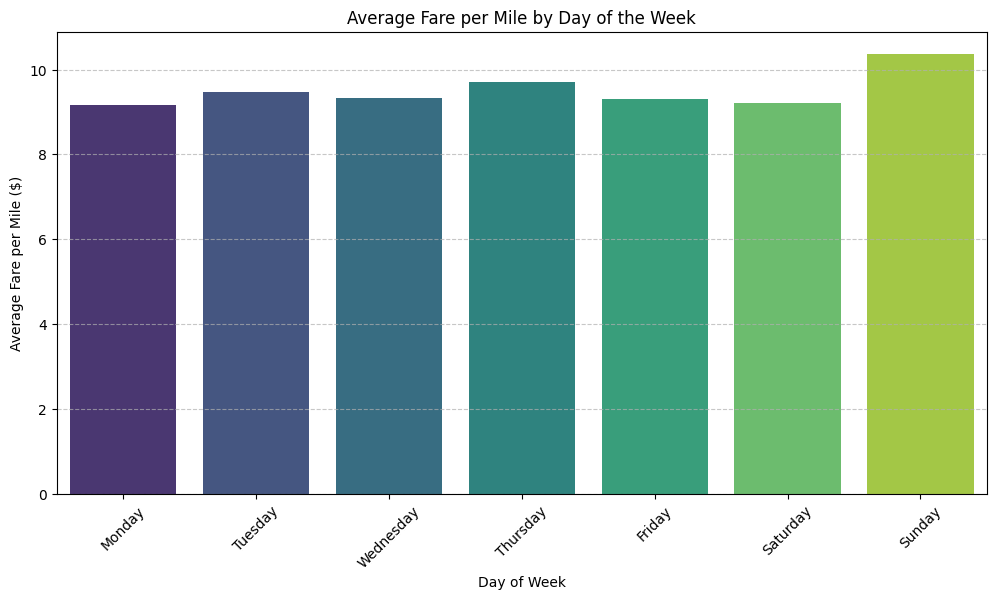

Average Fare per Mile by Day of the Week:


,fare_per_mile
pickup_day_of_week_name,
Monday,9.174991
Tuesday,9.476830
Wednesday,9.337837
Thursday,9.696461
Friday,9.315353
Saturday,9.202231
Sunday,10.370137


In [56]:
# Calculate average fare per mile by day of the week
average_fare_per_mile_by_day = df_fare_analysis.groupby('pickup_day_of_week_name')['fare_per_mile'].mean().reindex(day_names)

# Plot average fare per mile by day of the week
plt.figure(figsize=(12, 6))
sns.barplot(x=average_fare_per_mile_by_day.index, y=average_fare_per_mile_by_day.values, palette='viridis')
plt.title('Average Fare per Mile by Day of the Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Fare per Mile ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Fare per Mile by Day of the Week:")
display(average_fare_per_mile_by_day)

/tmp/ipykernel_1634/2709494871.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=average_fare_per_mile_by_hour.index, y=average_fare_per_mile_by_hour.values, palette='viridis')


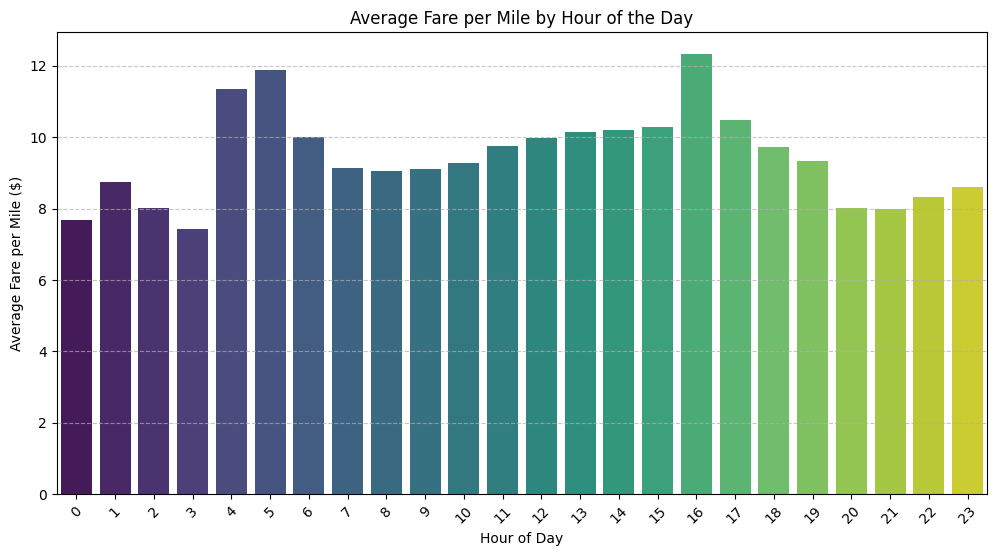

Average Fare per Mile by Hour of the Day:


,fare_per_mile
pickup_hour,
0,7.672424
1,8.736084
2,8.010001
3,7.423142
4,11.358534
5,11.895619
6,9.996013
7,9.129399
8,9.042463


In [57]:
# Calculate average fare per mile by hour of the day
average_fare_per_mile_by_hour = df_fare_analysis.groupby('pickup_hour')['fare_per_mile'].mean()

# Plot average fare per mile by hour of the day
plt.figure(figsize=(12, 6))
sns.barplot(x=average_fare_per_mile_by_hour.index, y=average_fare_per_mile_by_hour.values, palette='viridis')
plt.title('Average Fare per Mile by Hour of the Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare per Mile ($)')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Average Fare per Mile by Hour of the Day:")
display(average_fare_per_mile_by_hour)

**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

In [ ]:
# Compare fare per mile for different vendors



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


In [58]:
def get_distance_tier(distance):
    if distance <= 2:
        return '0-2 miles'
    elif 2 < distance <= 5:
        return '2-5 miles'
    else:
        return '5+ miles'

df_fare_analysis['distance_tier'] = df_fare_analysis['trip_distance'].apply(get_distance_tier)

# Calculate average fare per mile by vendor and distance tier
average_fare_per_mile_by_vendor_tier = df_fare_analysis.groupby(['VendorID', 'distance_tier'])['fare_per_mile'].mean().unstack()

print("Average Fare per Mile by Vendor and Distance Tier:")
display(average_fare_per_mile_by_vendor_tier)

Average Fare per Mile by Vendor and Distance Tier:


distance_tier,0-2 miles,2-5 miles,5+ miles
VendorID,,,
1,9.513499,6.355195,4.470793
2,13.589658,6.547440,4.505167


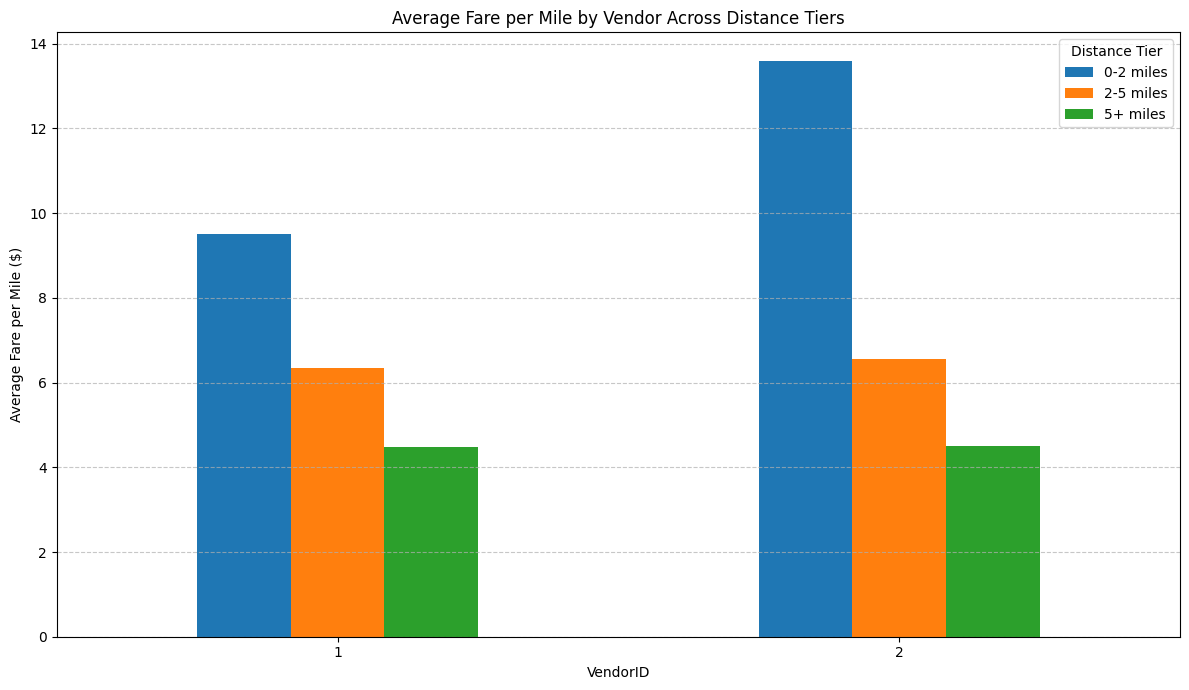

In [59]:
average_fare_per_mile_by_vendor_tier.plot(kind='bar', figsize=(12, 7))
plt.title('Average Fare per Mile by Vendor Across Distance Tiers')
plt.xlabel('VendorID')
plt.ylabel('Average Fare per Mile ($)')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Distance Tier')
plt.tight_layout()
plt.show()

In [60]:
# Defining distance tiers
df_fare_analysis['tip_percentage'] = (df_fare_analysis['tip_amount'] / df_fare_analysis['fare_amount']) * 100

average_tip_percentage_by_passenger = df_fare_analysis.groupby('passenger_count')['tip_percentage'].mean().reset_index()

print("Average Tip Percentage by Passenger Count:")
display(average_tip_percentage_by_passenger)


Average Tip Percentage by Passenger Count:


,passenger_count,tip_percentage
0,1.0,26.510170
1,2.0,25.817441
2,3.0,25.809132
3,4.0,25.891464
4,5.0,26.048419
5,6.0,26.161426


##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

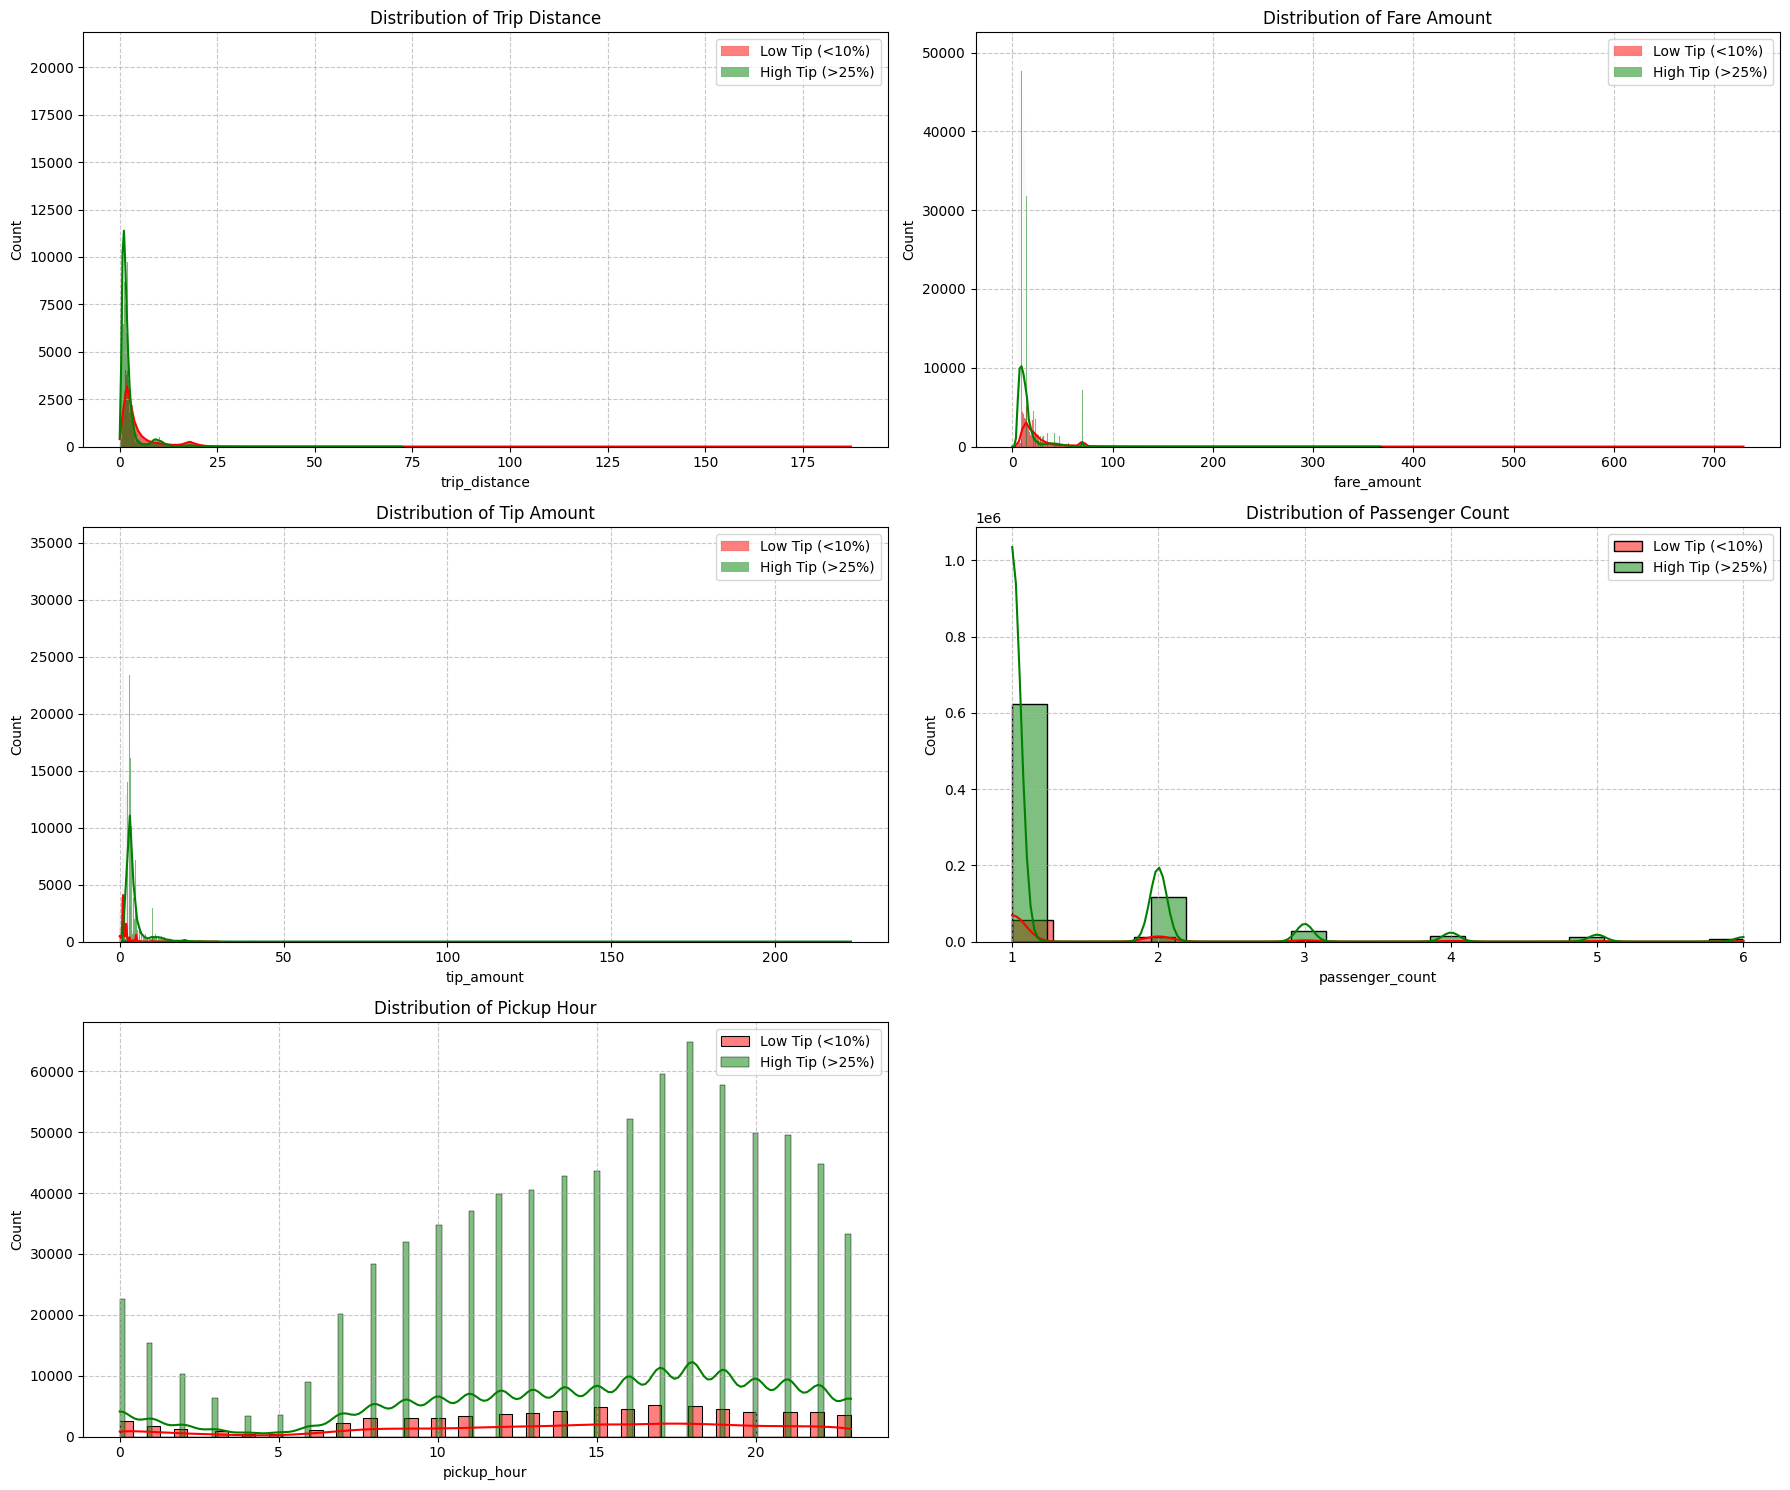

In [63]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
# Plot distributions for key variables for low vs. high tip percentage trips

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(18, 15))
axes = axes.flatten()

variables_to_plot = ['trip_distance', 'fare_amount', 'tip_amount', 'passenger_count', 'pickup_hour']

for i, var in enumerate(variables_to_plot):
    sns.histplot(low_tip_df[var], ax=axes[i], color='red', alpha=0.5, label='Low Tip (<10%)', kde=True)
    sns.histplot(high_tip_df[var], ax=axes[i], color='green', alpha=0.5, label='High Tip (>25%)', kde=True)
    axes[i].set_title(f'Distribution of {var.replace('_', ' ').title()}')
    axes[i].legend()
    axes[i].grid(True, linestyle='--', alpha=0.7)

# Remove any unused subplots
if len(variables_to_plot) < len(axes):
    for j in range(len(variables_to_plot), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [ ]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%



In [61]:
# Define low and high tip percentage groups
low_tip_df = df_fare_analysis[df_fare_analysis['tip_percentage'] < 10].copy()
high_tip_df = df_fare_analysis[df_fare_analysis['tip_percentage'] > 25].copy()

print("Descriptive Statistics for Low Tip Percentage Trips (<10%):")
display(low_tip_df[['trip_distance', 'passenger_count', 'fare_amount', 'tip_amount', 'pickup_hour']].describe())

print("\nDescriptive Statistics for High Tip Percentage Trips (>25%):")
display(high_tip_df[['trip_distance', 'passenger_count', 'fare_amount', 'tip_amount', 'pickup_hour']].describe())

Descriptive Statistics for Low Tip Percentage Trips (<10%):


,trip_distance,passenger_count,fare_amount,tip_amount,pickup_hour
count,74631.000000,74631.000000,74631.000000,74631.000000,74631.000000
mean,4.919093,1.378248,26.510030,1.686328,14.060136
std,5.647064,0.871708,23.096756,1.509284,6.089115
min,0.010000,1.000000,3.000000,0.010000,0.000000
25%,1.710000,1.000000,12.800000,1.000000,10.000000
50%,2.700000,1.000000,19.100000,1.000000,15.000000
75%,5.300000,1.000000,29.600000,2.000000,19.000000
max,187.350000,6.000000,728.900000,30.000000,23.000000



Descriptive Statistics for High Tip Percentage Trips (>25%):


,trip_distance,passenger_count,fare_amount,tip_amount,pickup_hour
count,800892.000000,800892.000000,800892.000000,800892.000000,800892.00000
mean,2.306573,1.369141,14.437490,4.430369,14.61346
std,2.910980,0.867193,11.661337,3.691466,5.81845
min,0.010000,1.000000,0.010000,0.870000,0.00000
25%,0.930000,1.000000,7.900000,2.700000,11.00000
50%,1.430000,1.000000,11.400000,3.360000,16.00000
75%,2.230000,1.000000,14.900000,4.470000,19.00000
max,72.280000,6.000000,367.000000,223.080000,23.00000


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

In [ ]:
# See how passenger count varies across hours and days




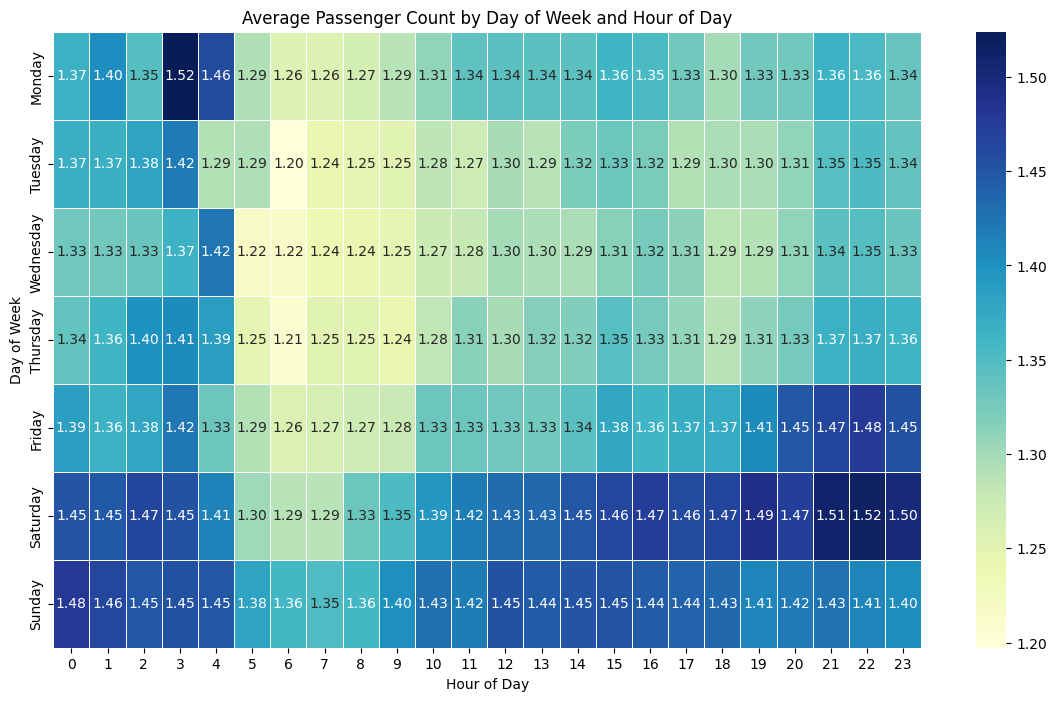

Average Passenger Count by Day of Week and Hour of Day:


pickup_hour,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
pickup_day_of_week_name,,,,,,,,,,,,,,,,,,,,,
Monday,1.366395,1.403413,1.347243,1.523918,1.460094,1.292063,1.256448,1.256960,1.267319,1.288921,...,1.341890,1.361516,1.353171,1.329470,1.298880,1.328447,1.328885,1.364617,1.355250,1.336087
Tuesday,1.368677,1.367308,1.380392,1.418685,1.290970,1.293388,1.197334,1.241149,1.247692,1.251502,...,1.321402,1.333831,1.323498,1.291394,1.295259,1.295141,1.310043,1.345614,1.352514,1.336913
Wednesday,1.330756,1.327891,1.334250,1.365239,1.422392,1.218595,1.216174,1.236437,1.241491,1.247199,...,1.294406,1.314816,1.323838,1.312713,1.286441,1.289764,1.310212,1.343851,1.346705,1.334772
Thursday,1.338636,1.360815,1.399806,1.405360,1.387283,1.247646,1.208863,1.252517,1.251426,1.242461,...,1.318886,1.345586,1.326969,1.309039,1.289109,1.311072,1.326164,1.366791,1.369041,1.363157
Friday,1.385302,1.364972,1.379118,1.421198,1.331962,1.291667,1.257815,1.265447,1.271706,1.276987,...,1.344254,1.377048,1.360723,1.369789,1.373124,1.405553,1.448078,1.466490,1.477012,1.454982
Saturday,1.451042,1.447284,1.466071,1.453315,1.413588,1.302115,1.288035,1.288014,1.332626,1.352750,...,1.449549,1.464902,1.473719,1.459973,1.465488,1.490822,1.472267,1.511050,1.515956,1.500417
Sunday,1.478688,1.464575,1.449856,1.454632,1.449471,1.380774,1.358367,1.351512,1.359268,1.402663,...,1.451173,1.451511,1.444807,1.438932,1.434160,1.411314,1.420580,1.426670,1.411566,1.404752


In [64]:
passenger_count_by_time = df_filtered.groupby(['pickup_day_of_week_name', 'pickup_hour'])['passenger_count'].mean().unstack()

# Reorder columns to ensure correct day order in the heatmap
day_names_ordered = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
passenger_count_by_time = passenger_count_by_time.reindex(day_names_ordered)

plt.figure(figsize=(14, 8))
sns.heatmap(passenger_count_by_time, cmap='YlGnBu', annot=True, fmt=".2f", linewidths=.5)
plt.title('Average Passenger Count by Day of Week and Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()

print("Average Passenger Count by Day of Week and Hour of Day:")
display(passenger_count_by_time)

**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [ ]:
# How does passenger count vary across zones



In [ ]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.



Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

In [ ]:
# How often is each surcharge applied?



In [65]:
surcharge_cols = ['extra', 'mta_tax', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']
total_trips = len(df_filtered)

surcharge_prevalence = {}
for col in surcharge_cols:
    applied_count = (df_filtered[col] > 0).sum()
    applied_proportion = (applied_count / total_trips) * 100
    surcharge_prevalence[col] = {'Applied Count': applied_count, 'Proportion (%)': applied_proportion}

surcharge_prevalence_df = pd.DataFrame.from_dict(surcharge_prevalence, orient='index')

print("Prevalence of Surcharges:")
display(surcharge_prevalence_df.sort_values(by='Proportion (%)', ascending=False))

Prevalence of Surcharges:


,Applied Count,Proportion (%)
improvement_surcharge,1412884,99.998514
mta_tax,1404896,99.433154
congestion_surcharge,1341457,94.943184
extra,897678,63.534208
airport_fee,116155,8.221006
tolls_amount,114484,8.102739


## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

### Recommendations for Routing and Dispatching Optimization

Based on the analysis of temporal and geographical demand patterns, along with operational insights, the following recommendations can be made to optimize routing and dispatching:

1.  **Dynamic Positioning based on Hourly Demand:**
    *   **Insight:** The hourly pickup distribution clearly shows peak demand periods (17:00-19:00 on weekdays, and generally consistent activity throughout weekend days, with a slight evening peak). Early mornings (1:00-5:00) are generally quietest.
    *   **Recommendation:** Implement a dynamic dispatching system that pre-positions cabs to high-demand zones just before peak hours. For example, increase fleet density in key pickup zones like Midtown East, Upper East Side South, and JFK Airport around 16:00-17:00 on weekdays.

2.  **Zone-Specific Supply Management:**
    *   **Insight:** Certain zones consistently exhibit high pickup and dropoff activity (e.g., Midtown East, Upper East Side South, JFK Airport). Some zones also show significantly high or low pickup-to-dropoff ratios (e.g., JFK Airport with a very high ratio, suggesting more pickups than dropoffs, while East Harlem North has a low ratio, indicating more dropoffs than pickups).
    *   **Recommendation:**
        *   **High Pickup/Low Dropoff Zones (e.g., JFK Airport):** Actively direct available cabs to these areas to meet outgoing demand, especially during peak travel times to and from the airport.
        *   **Low Pickup/High Dropoff Zones (e.g., East Harlem North):** Strategically re-route cabs from these zones to nearby high-demand areas after dropping off passengers to minimize idle time and empty returns.

3.  **Night Hour Specialization:**
    *   **Insight:** Specific zones maintain significant activity during night hours (11 PM - 5 AM), such as JFK Airport and Midtown East for pickups, and East Chelsea, Lenox Hill West for dropoffs. Night hours contribute a substantial, albeit smaller, share of total revenue (~12%).
    *   **Recommendation:** Develop a dedicated night-shift dispatching strategy focusing on these consistently active zones. Consider offering incentives for drivers operating in these areas during night hours to ensure adequate supply, potentially using dynamic pricing to reflect demand and incentivize drivers.

4.  **Route Optimization to Avoid Slow Areas:**
    *   **Insight:** Identification of 'slow routes' (low average speed routes) highlights operational inefficiencies, likely due to congestion or less direct paths.
    *   **Recommendation:** Integrate real-time traffic data and historical slow route patterns into the routing algorithm. Dispatchers and drivers should be advised to avoid historically slow routes during specific times, or alternative routes should be suggested to improve trip efficiency and reduce fuel consumption.

5.  **Weekend vs. Weekday Strategy Differentiation:**
    *   **Insight:** Weekdays show a distinct morning and evening commute peak, while weekends have a more spread-out demand pattern with a later peak (afternoon/evening).
    *   **Recommendation:** Adjust dispatching patterns based on the day type. For weekdays, prioritize core business districts and transport hubs during commute hours. For weekends, focus more on entertainment, retail, and residential areas, adapting to the later peak demand.

By implementing these data-driven strategies, the taxi operation can proactively manage its fleet, reduce idle times, improve service reliability, and ultimately enhance both driver efficiency and customer satisfaction.

**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

### Revenue Impact of Dynamic Surge Pricing

In [66]:
# Define peak and off-peak hours/days based on previous analysis

# Weekday (Monday-Friday: 0-4) peak hours (4 PM - 8 PM)
WEEKDAY_PEAK_START = 16
WEEKDAY_PEAK_END = 20

# Weekend (Saturday-Sunday: 5-6) peak hours (6 PM - 10 PM)
WEEKEND_PEAK_START = 18
WEEKEND_PEAK_END = 22

# Off-peak hours (1 AM - 5 AM) for all days
OFF_PEAK_START = 1
OFF_PEAK_END = 5

# Define hypothetical surge multipliers and discounts
SURGE_MULTIPLIER = 1.20  # 20% increase for peak hours
DISCOUNT_MULTIPLIER = 0.90 # 10% decrease for off-peak hours

def get_pricing_category(row):
    hour = row['pickup_hour']
    day_of_week = row['pickup_day_of_week'] # 0=Monday, 6=Sunday

    # Check for Weekday Peak
    if day_of_week >= 0 and day_of_week <= 4 and hour >= WEEKDAY_PEAK_START and hour < WEEKDAY_PEAK_END:
        return 'Peak'
    # Check for Weekend Peak
    elif day_of_week >= 5 and day_of_week <= 6 and hour >= WEEKEND_PEAK_START and hour < WEEKEND_PEAK_END:
        return 'Peak'
    # Check for Off-Peak
    elif hour >= OFF_PEAK_START and hour < OFF_PEAK_END:
        return 'Off-Peak'
    else:
        return 'Normal'

df_pricing = df_filtered.copy()
df_pricing['pricing_category'] = df_pricing.apply(get_pricing_category, axis=1)

# Calculate current revenue for each category
current_revenue_by_category = df_pricing.groupby('pricing_category')['total_amount'].sum()
current_total_revenue = df_pricing['total_amount'].sum()

print("Current Revenue by Pricing Category:")
display(current_revenue_by_category)
print(f"\nCurrent Total Revenue: ${current_total_revenue:,.2f}")

Current Revenue by Pricing Category:


,total_amount
pricing_category,
Normal,28895905.38
Off-Peak,1659561.18
Peak,11236001.35



Current Total Revenue: $41,791,467.91


### Interpretation of Revenue Impact

Based on the hypothetical dynamic pricing model:

*   **Peak Hour/Day Surge:** Applying a 20% surge during defined peak periods could lead to a significant increase in revenue from these categories.
*   **Off-Peak Hour Discount:** A 10% discount during off-peak hours might slightly decrease revenue from these periods but could help to:
    *   **Balance Demand:** Encourage ridership during otherwise quiet hours, potentially reducing idle time for drivers and better utilizing the fleet.
    *   **Improve Customer Experience:** Offer more competitive rates when demand is naturally lower.
*   **Overall Impact:** The overall change in total revenue indicates the net effect of these adjustments. A positive overall change suggests that the gains from peak hour surging outweigh the losses from off-peak discounting and unchanged normal period pricing.

**Considerations for Implementation:**

1.  **Customer Acceptance:** Transparency is key. Customers should understand *why* prices fluctuate. Clear in-app notifications and explanations can mitigate negative reactions.
2.  **Competitor Analysis:** Continuously monitor competitor pricing during peak and off-peak times to ensure the dynamic pricing remains competitive and attractive.
3.  **Elasticity of Demand:** The actual impact depends on how sensitive customers are to price changes. Further A/B testing or smaller-scale pilots could refine the multipliers.
4.  **Driver Incentives:** Ensure drivers are appropriately compensated during surge pricing to maintain motivation and supply during high-demand periods.

### Strategic Cab Positioning based on Trip Trends

To optimize cab positioning, a multi-faceted approach considering temporal and geographical demand is crucial. The goal is to minimize idle time and maximize service availability where and when it's most needed.

1.  **Time-Based Pre-positioning:**
    *   **Morning Rush (6 AM - 9 AM weekdays):** High demand in residential areas like Upper East Side, Upper West Side, and financial districts (e.g., Midtown East). Cabs should be strategically positioned in these residential zones starting around 5:30 AM to capture early commuters and then directed towards business hubs as demand shifts.
    *   **Lunchtime Peak (12 PM - 2 PM weekdays):** Consistent demand across commercial and business districts. Ensure a strong presence in Midtown East, Midtown Center, and surrounding areas.
    *   **Evening Peak (5 PM - 7 PM weekdays):** Highest overall demand. Focus on major transport hubs (e.g., Penn Station/Madison Sq West), business districts (Midtown areas), and entertainment zones. Anticipate outflows from these areas to various residential zones.
    *   **Night Hours (11 PM - 5 AM):** While overall demand is lower, certain zones remain active. Prioritize coverage in JFK Airport and Midtown East for pickups, and anticipate drop-offs in areas like East Chelsea and Lenox Hill West. A dedicated night-shift fleet should be optimized for these specific high-activity night zones.

2.  **Zone-Specific Allocation and Rebalancing:**
    *   **High Pickup Ratio Zones (e.g., JFK Airport, LaGuardia Airport, Murray Hill, East Village):** These zones consistently generate more pickups than drop-offs. Cabs should be actively directed towards these areas, especially during their peak hours, to prevent supply shortages. Consider a 'return-to-base' strategy or designated waiting areas for cabs after dropping off passengers in surrounding low-pickup areas.
    *   **Low Pickup Ratio Zones (e.g., East Harlem North, University Heights/Morris Heights):** These areas often have more drop-offs than pickups. After dropping off passengers in these zones, cabs should be efficiently re-routed to nearby high-demand pickup zones rather than waiting for a local pickup. This could involve real-time dispatching instructions.
    *   **Balanced Zones (e.g., Midtown Center, West Village):** Maintain a flexible fleet presence, as these zones tend to have a more even flow of pickups and drop-offs. Dynamic allocation based on real-time demand fluctuations would be most effective here.

3.  **Weekday vs. Weekend Strategy:**
    *   **Weekdays:** Emphasize business and commuter routes. Positioning should cater to the distinct morning and evening peaks in and out of financial and commercial districts.
    *   **Weekends:** Shift focus towards entertainment areas (e.g., Times Sq/Theatre District, East Village), residential neighborhoods, and tourist attractions. Demand is more spread out, with a later peak, requiring more flexible routing.

4.  **Leveraging Real-Time Data:**
    *   Integrate real-time traffic data and current demand heatmaps into the dispatching system. This allows for immediate adjustments to cab positioning, avoiding congested areas (identified as 'slow routes') and directing drivers to areas with sudden spikes in demand.

By implementing these strategies, the taxi operation can proactively manage its fleet, reduce driver idle time, improve response times for customers, and ultimately enhance overall operational efficiency and profitability.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

In [ ]:
import os
print(os.getcwd())